# Large Language Models en el Dominio Tabular: Estudio Comparativo en Clasificación de Datos Médicos

**Trabajo Fin de Grado**

* **Nombre:** Álvaro Manso Horcajada
* **Grado:** Ciencia e Ingeniería de Datos, Universidad Rey Juan Carlos
* **Curso:** 2025-2026

## Librerías

In [1]:
# --- LIBRERÍAS ---

# Conjuntos de datos

#   Exploración inicial
from ucimlrepo import fetch_ucirepo

#   Partición de los datos
from sklearn.model_selection import train_test_split

#   Análisis exploratorio de datos
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#   Preprocesamiento
import io
import zipfile
import requests
from mrmr import mrmr_classif

# Modelos tradicionales
import time
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#   Árbol de decisión
from sklearn.tree import DecisionTreeClassifier

#   Random Forest
from sklearn.ensemble import RandomForestClassifier

#   XGBoost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Large Language Models

#   Few-shot
import random

#   Modelos
import gc
import json
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

#   Pipeline
import sys
from datetime import datetime

#   Retrieval-Augmented Generation
import chromadb
from chromadb.utils import embedding_functions

# Comparación de resultados
import re

## Configuración

In [2]:
# --- CONFIGURACIÓN GLOBAL ---

# Semillas para los experimentos
SEMILLAS = [27182, 11235, 16180]

In [3]:
# --- CONFIGURACIÓN DE LOS CONJUNTOS DE DATOS ---

# Proporción de datos para el conjunto de test
DIMENSION_TEST = 0.3

# Semilla para la partición de los datos y preprocesamiento
SEMILLA = 31415

# Directorios de salida para las figuras del EDA
DIRECTORIO_FIGURAS_EDA = "tfg_figuras_eda"

In [4]:
# --- CONFIGURACIÓN DEL PREPROCESAMIENTO DE DRUG INDUCED AUTOIMMUNITY PREDICTION ---

# Definición de la proporción de observaciones para cada clase
NUMERO_OBSERVACIONES = 300
NUMERO_OBSERVACIONES_CLASE_MAYORITARIA = int(NUMERO_OBSERVACIONES * 0.65)
NUMERO_OBSERVACIONES_CLASE_MINORITARIA = int(NUMERO_OBSERVACIONES * 0.35)

# Umbral de frecuencia para identificar variables casi constantes
UMBRAL_FRECUENCIA = 0.90

# Definición del número de características a seleccionar con mRMR
NUMERO_CARACTERISTICAS = 15

In [5]:
# --- CONFIGURACIÓN DE LOS LARGE LANGUAGE MODELS ---

# Definición de los modelos LLM y sus tamaños
# Estimaciones de memoria: [parámetros * 2 bytes (float16)] * 1.15 (factor de seguridad para memoria adicional)
MODELOS_LLM = {
    "qwen": [
        ("small", "Qwen/Qwen2.5-7B-Instruct", round(7*2*1.15)), 
        ("medium", "Qwen/Qwen2.5-14B-Instruct", round(14*2*1.15)),
        ("large", "Qwen/Qwen2.5-72B-Instruct", round(72*2*1.15))
    ],
    "deepseek": [
        ("small", "deepseek-ai/deepseek-llm-7b-chat", round(7*2*1.15)),
        ("medium", "deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct", round(14*2*1.15)),
        ("large", "deepseek-ai/deepseek-llm-67b-chat", round(67*2*1.15))
    ],
    "mistral": [
        ("small", "mistralai/Ministral-8B-Instruct-2410", round(8*2*1.15)),
        ("medium", "mistralai/Mistral-Nemo-Instruct-2407", round(12*2*1.15)),
        ("large", "mistralai/Mixtral-8x7B-Instruct-v0.1", round(47*2*1.15))
    ]
}

# Tipos de serialización
SERIALIZACIONES = ["list", "text"]

# Número de ejemplos de contexto para few-shot
SHOTS = [0, 1, 2, 4, 8]

# Definición de las columnas de serialización
COLUMNAS_SERIALIZACION = {
    "list": "List template serialization",
    "text": "Text template serialization"
}

In [6]:
# --- CONFIGURACIÓN DE LA BASE DE DATOS VECTORIAL ---

# Ruta donde se almacenará la base de datos de ChromaDB
RUTA_BD_CHROMA = "./tfg_chroma_bd"

# Modelo de alta precisión semántica
MODELO_EMBEDDING = "all-mpnet-base-v2"

In [7]:
# --- CONFIGURACIÓN  DE LA COMPARACIÓN DE RESULTADOS ---

# Directorios de salida para las figuras y tablas de resultados
DIRECTORIO_FIGURAS_RESULTADOS = "tfg_figuras_resultados"
DIRECTORIO_TABLAS_RESULTADOS  = "tfg_tablas_resultados"

# Marcadores para resaltar en negrita los valores más altos de cada métrica
MARCADOR_NEGRITA_INICIO = "@@B@@"
MARCADOR_NEGRITA_FIN = "@@/B@@"

# Orden canónico de las categorías (para ejes y leyendas consistentes)
ORDEN_DATASETS = ["Heart", "Cancer", "DIA"]
ORDEN_TAMANOS  = ["Small", "Medium", "Large"]
ORDEN_FAMILIAS = ["Qwen", "DeepSeek", "Mistral"]
ORDEN_SHOTS    = [0, 1, 2, 4, 8]

## Conjuntos de datos

### Heart Failure Clinical Records

#### Exploración inicial

In [8]:
# Recuperar el conjunto de datos 
heart_failure_clinical_records = fetch_ucirepo(id=519) 

# Variables
X_heart = heart_failure_clinical_records.data.features 
y_heart = heart_failure_clinical_records.data.targets 
  
# Información del conjunto de datos
print(heart_failure_clinical_records.metadata) 
  
# Información de las variables
print(heart_failure_clinical_records.variables) 

{'uci_id': 519, 'name': 'Heart Failure Clinical Records', 'repository_url': 'https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records', 'data_url': 'https://archive.ics.uci.edu/static/public/519/data.csv', 'abstract': 'This dataset contains the medical records of 299 patients who had heart failure, collected during their follow-up period, where each patient profile has 13 clinical features.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 299, 'num_features': 12, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['death_event'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5Z89R', 'creators': [], 'intro_paper': {'ID': 286, 'type': 'NATIVE', 'title': 'Machine learning can predict survival of patients with heart failure f

In [9]:
# Mostrar las primeras filas de las características
print(X_heart.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  
0        0     4  
1        0     6  
2        1     7  
3        0     7  
4        

In [10]:
# Mostrar las primeras filas de la variable objetivo
print(y_heart.head())

   death_event
0            1
1            1
2            1
3            1
4            1


In [11]:
# Resumen de las variables
print(X_heart.describe())

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

In [12]:
# Resumen de la variable objetivo
print(y_heart.describe())

       death_event
count    299.00000
mean       0.32107
std        0.46767
min        0.00000
25%        0.00000
50%        0.00000
75%        1.00000
max        1.00000


#### Partición de los datos

In [13]:
def particionar_datos(X, y, seed):
    """
    Particiona los datos en conjuntos de entrenamiento y test
    """
    
    # Separamos un 30% de los datos para el conjunto de test
    # y el 70% restante para el conjunto de entrenamiento
    # Usamos stratify=y para asegurar una distribución similar de la variable objetivo
    # y random_state para reproducibilidad

    X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
      X, y, test_size=DIMENSION_TEST, random_state=seed, stratify=y
    )

    return X_entrenamiento, X_test, y_entrenamiento, y_test

In [14]:
# Particionar los datos
X_entrenamiento_heart, X_test_heart, y_entrenamiento_heart, y_test_heart = particionar_datos(
    X_heart, 
    y_heart, 
    seed=SEMILLA
)

print(f"Dimensiones de los conjuntos de datos:")
print(f"    X_entrenamiento_heart: {X_entrenamiento_heart.shape}")
print(f"    X_test_heart:          {X_test_heart.shape}")
print(f"    y_entrenamiento_heart: {y_entrenamiento_heart.shape}")
print(f"    y_test_heart:          {y_test_heart.shape}")

Dimensiones de los conjuntos de datos:
    X_entrenamiento_heart: (209, 12)
    X_test_heart:          (90, 12)
    y_entrenamiento_heart: (209, 1)
    y_test_heart:          (90, 1)


#### Análisis exploratorio de datos

In [15]:
# 1. Configurar el estilo visual para los gráficos 
sns.set_theme(style="whitegrid")

# 2. Función para realizar el análisis exploratorio de datos
def realizar_eda(df, nombre_dataset):
    """
    Realiza un análisis exploratorio de datos (EDA)
    y guarda cada gráfico
    """
    
    variables = df.columns
    
    for col in variables:
        print(f"--- {col.upper()} ---\n")
        
        series = df[col]
        
        # 1. Análisis básicos
        tipo = series.dtype
        nulos = series.isnull().sum()
        valores_unicos = series.nunique()
        
        print(f"Tipo de dato: {tipo}")
        print(f"Valores nulos: {nulos} ({nulos/len(df):.2%})")
        print(f"Valores únicos: {valores_unicos}")
        
        # 2. Distinción categórica vs continua
        # Consideramos categórica si es tipo objeto/category 
        # O si es numérica pero con pocos valores únicos (<= 15, para rangos)
        es_categorica = False
        if pd.api.types.is_object_dtype(series) or isinstance(tipo, pd.CategoricalDtype):
            es_categorica = True
        elif pd.api.types.is_numeric_dtype(series) and valores_unicos <= 15:
            es_categorica = True
            
        # 3. Visualización y estadísticos
        plt.figure(figsize=(10, 4))

        # Configuración de la rejilla
        plt.gca().set_axisbelow(True)
        plt.grid(True, linestyle="--", alpha=0.3, color="gray")
        
        if es_categorica:
            # --- Tratamiento categórico ---
            print("\nFrecuencia de valores:")
            print(series.value_counts())
            
            # Gráfico de barras
            sns.countplot(x=series, hue=series, legend=False)
            plt.ylabel("Frecuencia")
            
        else:
            # --- Tratamiento continuo ---
            print("\nEstadísticos descriptivos:")
            print(series.describe())
            
            # Histograma con estimación de densidad (KDE)
            sns.histplot(series, kde=True, bins=20)
            plt.ylabel("Frecuencia")
            
        plt.tight_layout()

        # 4. Guardar la figura
        directorio_dataset = f"{DIRECTORIO_FIGURAS_EDA}_{nombre_dataset}"
        os.makedirs(directorio_dataset, exist_ok=True)

        ruta_figura = os.path.join(directorio_dataset, f"{col}.png")
        plt.savefig(ruta_figura, bbox_inches="tight", dpi=300)
        print(f"\nFigura guardada: {ruta_figura}")

        # 5. Mostrar la figura
        plt.show()

--- AGE ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 47

Estadísticos descriptivos:
count    299.000000
mean      60.833893
std       11.894809
min       40.000000
25%       51.000000
50%       60.000000
75%       70.000000
max       95.000000
Name: age, dtype: float64

Figura guardada: tfg_figuras_eda_heart/age.png


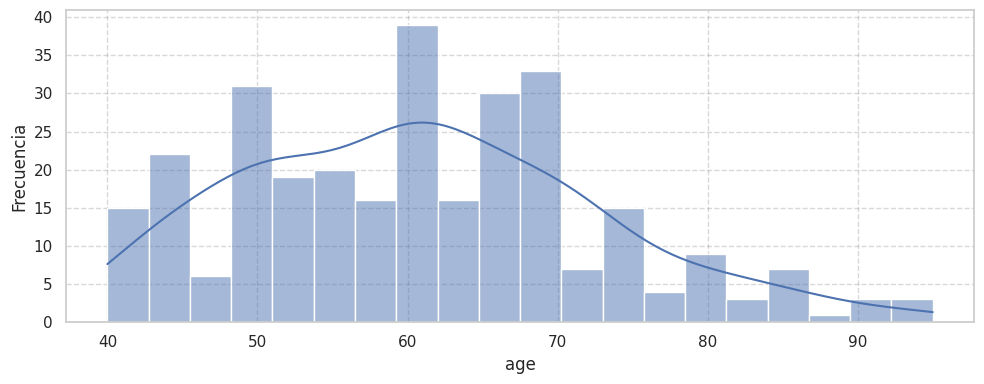

--- ANAEMIA ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
anaemia
0    170
1    129
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_heart/anaemia.png


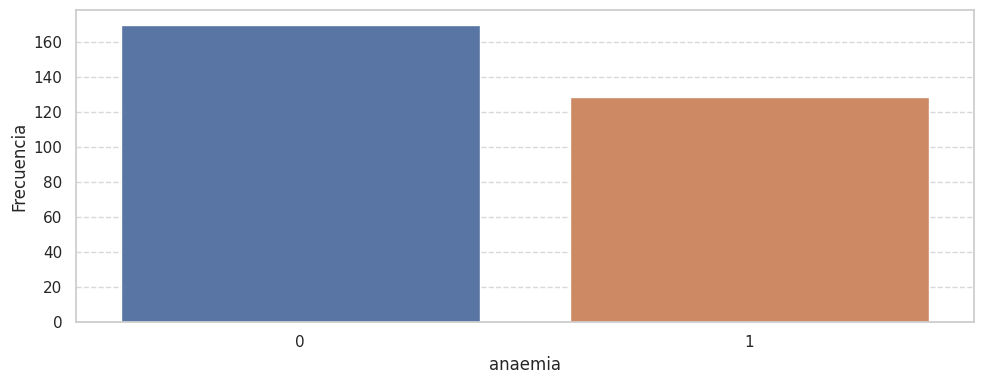

--- CREATININE_PHOSPHOKINASE ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 208

Estadísticos descriptivos:
count     299.000000
mean      581.839465
std       970.287881
min        23.000000
25%       116.500000
50%       250.000000
75%       582.000000
max      7861.000000
Name: creatinine_phosphokinase, dtype: float64

Figura guardada: tfg_figuras_eda_heart/creatinine_phosphokinase.png


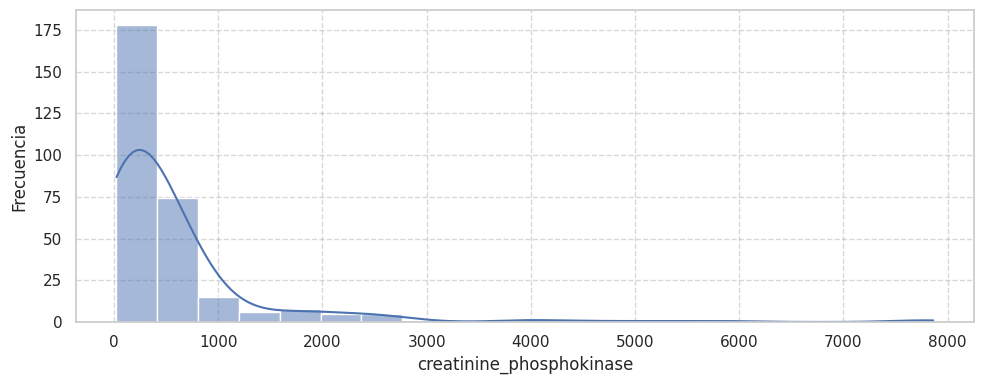

--- DIABETES ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
diabetes
0    174
1    125
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_heart/diabetes.png


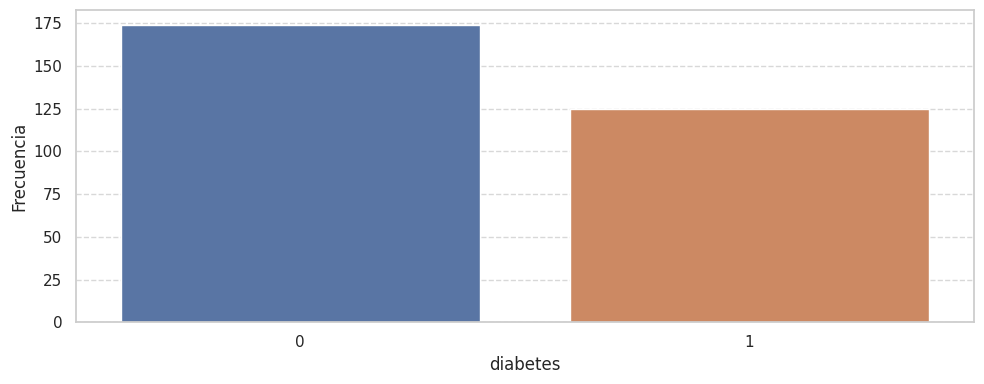

--- EJECTION_FRACTION ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 17

Estadísticos descriptivos:
count    299.000000
mean      38.083612
std       11.834841
min       14.000000
25%       30.000000
50%       38.000000
75%       45.000000
max       80.000000
Name: ejection_fraction, dtype: float64

Figura guardada: tfg_figuras_eda_heart/ejection_fraction.png


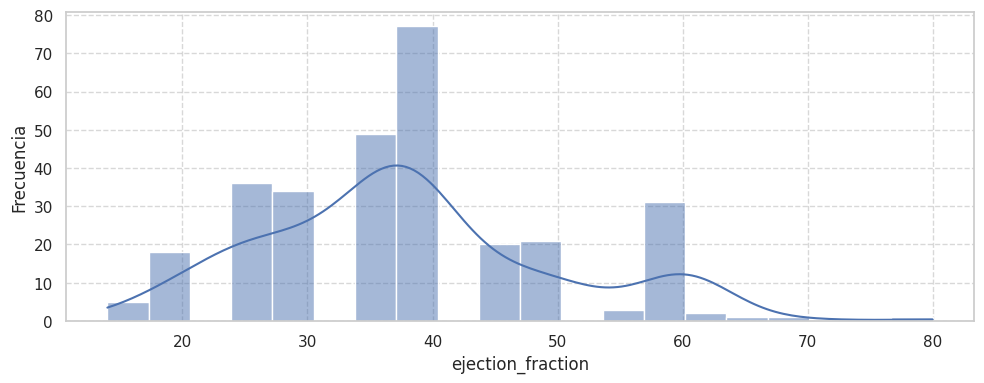

--- HIGH_BLOOD_PRESSURE ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
high_blood_pressure
0    194
1    105
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_heart/high_blood_pressure.png


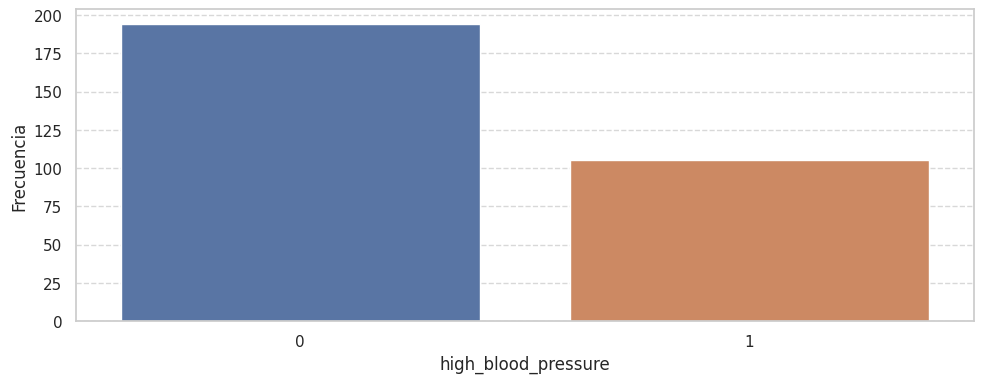

--- PLATELETS ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 176

Estadísticos descriptivos:
count       299.000000
mean     263358.029264
std       97804.236869
min       25100.000000
25%      212500.000000
50%      262000.000000
75%      303500.000000
max      850000.000000
Name: platelets, dtype: float64

Figura guardada: tfg_figuras_eda_heart/platelets.png


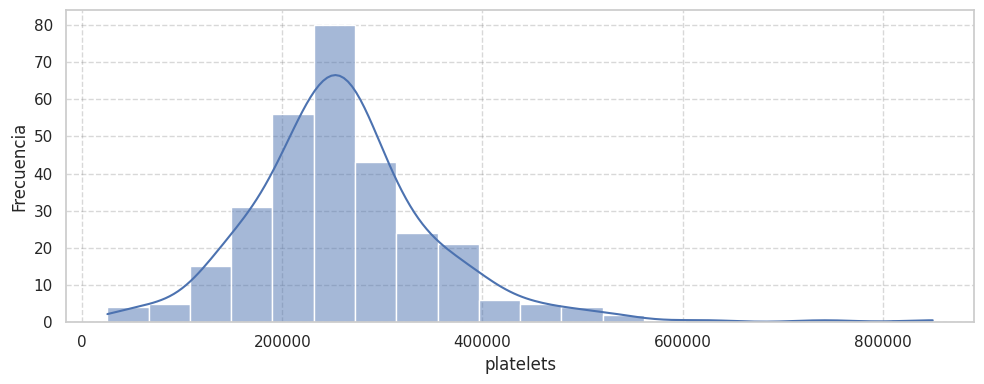

--- SERUM_CREATININE ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 40

Estadísticos descriptivos:
count    299.00000
mean       1.39388
std        1.03451
min        0.50000
25%        0.90000
50%        1.10000
75%        1.40000
max        9.40000
Name: serum_creatinine, dtype: float64

Figura guardada: tfg_figuras_eda_heart/serum_creatinine.png


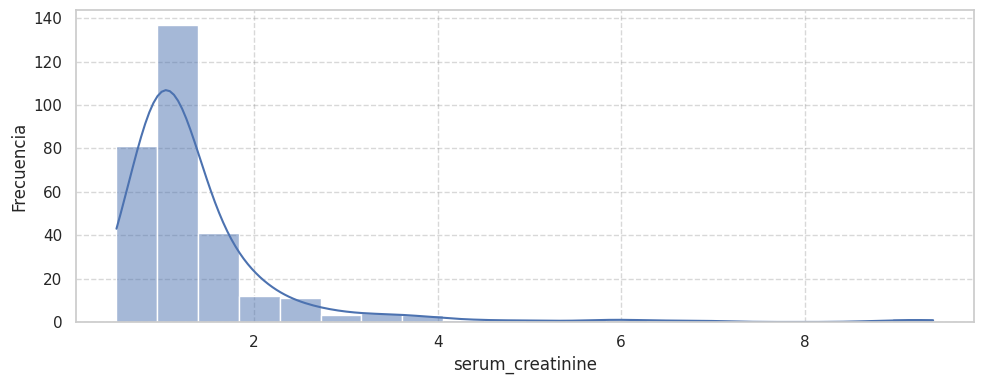

--- SERUM_SODIUM ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 27

Estadísticos descriptivos:
count    299.000000
mean     136.625418
std        4.412477
min      113.000000
25%      134.000000
50%      137.000000
75%      140.000000
max      148.000000
Name: serum_sodium, dtype: float64

Figura guardada: tfg_figuras_eda_heart/serum_sodium.png


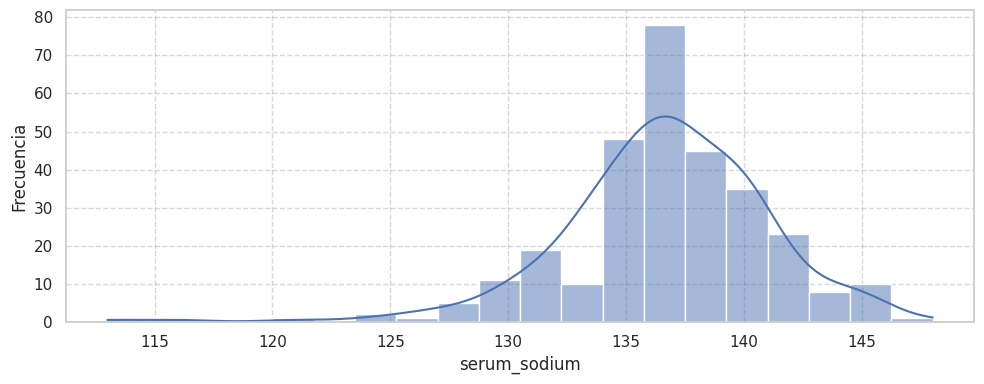

--- SEX ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
sex
1    194
0    105
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_heart/sex.png


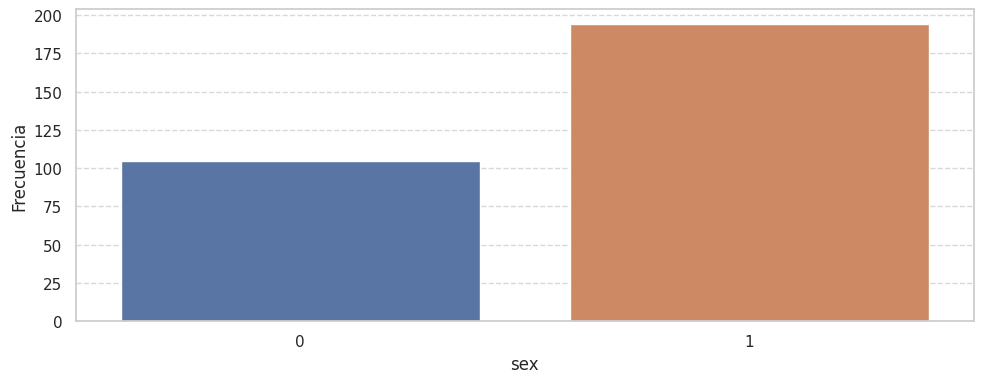

--- SMOKING ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
smoking
0    203
1     96
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_heart/smoking.png


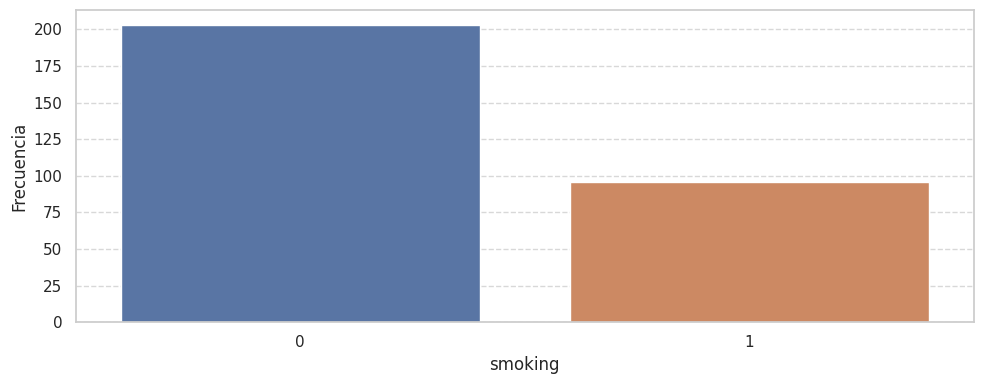

--- TIME ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 148

Estadísticos descriptivos:
count    299.000000
mean     130.260870
std       77.614208
min        4.000000
25%       73.000000
50%      115.000000
75%      203.000000
max      285.000000
Name: time, dtype: float64

Figura guardada: tfg_figuras_eda_heart/time.png


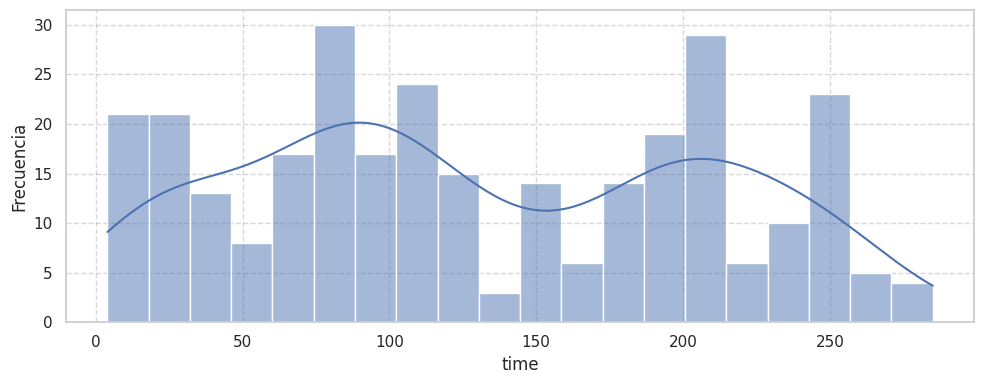

In [16]:
# Realizar EDA de las características
realizar_eda(X_heart, "heart")

--- DEATH_EVENT ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
death_event
0    203
1     96
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_heart/death_event.png


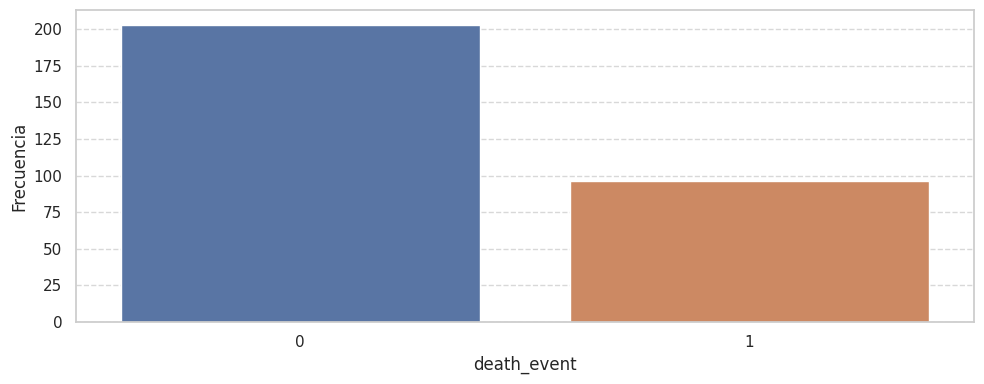

In [17]:
# Realizar EDA de la variable objetivo
realizar_eda(y_heart, "heart")

### Breast Cancer Coimbra

#### Exploración inicial

In [18]:
# Recuperar el conjunto de datos 
breast_cancer_coimbra = fetch_ucirepo(id=451) 
  
# Variables
X_cancer = breast_cancer_coimbra.data.features 
y_cancer = breast_cancer_coimbra.data.targets 
  
# Información del conjunto de datos
print(breast_cancer_coimbra.metadata) 

# Información de las variables
print(breast_cancer_coimbra.variables)

{'uci_id': 451, 'name': 'Breast Cancer Coimbra', 'repository_url': 'https://archive.ics.uci.edu/dataset/451/breast+cancer+coimbra', 'data_url': 'https://archive.ics.uci.edu/static/public/451/data.csv', 'abstract': 'Clinical features were observed or measured for 64 patients with breast cancer and 52 healthy controls. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 116, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': ['Age'], 'target_col': ['Classification'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C52P59', 'creators': ['Miguel Patrcio', 'Jos Pereira', 'Joana Crisstomo', 'Paulo Matafome', 'Raquel Seia', 'Francisco Caramelo'], 'intro_paper': {'ID': 431, 'type': 'NATIVE', 'title': 'Using Resistin, glucose, age and BMI to predict the presence of breast cancer', 'authors': 'M.

In [19]:
# Mostrar las primeras filas de las características
print(X_cancer.head())

   Age        BMI  Glucose  Insulin      HOMA   Leptin  Adiponectin  Resistin  \
0   48  23.500000       70    2.707  0.467409   8.8071     9.702400   7.99585   
1   83  20.690495       92    3.115  0.706897   8.8438     5.429285   4.06405   
2   82  23.124670       91    4.498  1.009651  17.9393    22.432040   9.27715   
3   68  21.367521       77    3.226  0.612725   9.8827     7.169560  12.76600   
4   86  21.111111       92    3.549  0.805386   6.6994     4.819240  10.57635   

     MCP.1  
0  417.114  
1  468.786  
2  554.697  
3  928.220  
4  773.920  


In [20]:
# Mostrar las primeras filas de la variable objetivo
print(y_cancer.head())

   Classification
0               1
1               1
2               1
3               1
4               1


In [21]:
# Resumen de las variables
print(X_cancer.describe())

              Age         BMI     Glucose     Insulin        HOMA      Leptin  \
count  116.000000  116.000000  116.000000  116.000000  116.000000  116.000000   
mean    57.301724   27.582111   97.793103   10.012086    2.694988   26.615080   
std     16.112766    5.020136   22.525162   10.067768    3.642043   19.183294   
min     24.000000   18.370000   60.000000    2.432000    0.467409    4.311000   
25%     45.000000   22.973205   85.750000    4.359250    0.917966   12.313675   
50%     56.000000   27.662416   92.000000    5.924500    1.380939   20.271000   
75%     71.000000   31.241442  102.000000   11.189250    2.857787   37.378300   
max     89.000000   38.578759  201.000000   58.460000   25.050342   90.280000   

       Adiponectin    Resistin        MCP.1  
count   116.000000  116.000000   116.000000  
mean     10.180874   14.725966   534.647000  
std       6.843341   12.390646   345.912663  
min       1.656020    3.210000    45.843000  
25%       5.474283    6.881763   269.978

In [22]:
# Resumen de la variable objetivo
print(y_cancer.describe())

       Classification
count      116.000000
mean         1.551724
std          0.499475
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000


#### Partición de los datos

In [23]:
# Particionar los datos
X_entrenamiento_cancer, X_test_cancer, y_entrenamiento_cancer, y_test_cancer = particionar_datos(
    X_cancer, 
    y_cancer, 
    seed=SEMILLA
)

print(f"Dimensiones de los conjuntos de datos:")
print(f"    X_entrenamiento_cancer: {X_entrenamiento_cancer.shape}")
print(f"    X_test_cancer:          {X_test_cancer.shape}")
print(f"    y_entrenamiento_cancer: {y_entrenamiento_cancer.shape}")
print(f"    y_test_cancer:          {y_test_cancer.shape}")

Dimensiones de los conjuntos de datos:
    X_entrenamiento_cancer: (81, 9)
    X_test_cancer:          (35, 9)
    y_entrenamiento_cancer: (81, 1)
    y_test_cancer:          (35, 1)


#### Análisis exploratorio de datos

--- AGE ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 51

Estadísticos descriptivos:
count    116.000000
mean      57.301724
std       16.112766
min       24.000000
25%       45.000000
50%       56.000000
75%       71.000000
max       89.000000
Name: Age, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/Age.png


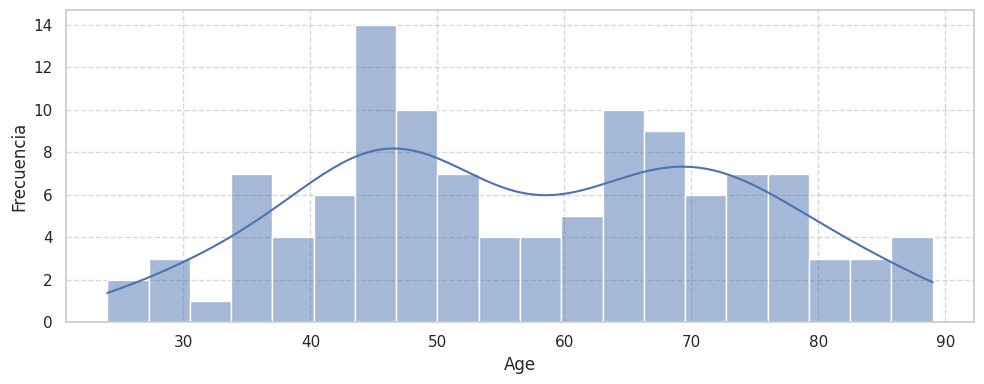

--- BMI ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 110

Estadísticos descriptivos:
count    116.000000
mean      27.582111
std        5.020136
min       18.370000
25%       22.973205
50%       27.662416
75%       31.241442
max       38.578759
Name: BMI, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/BMI.png


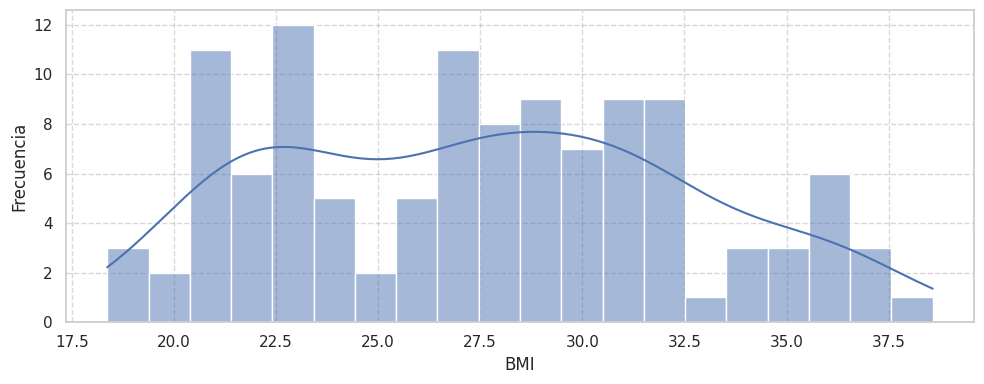

--- GLUCOSE ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 50

Estadísticos descriptivos:
count    116.000000
mean      97.793103
std       22.525162
min       60.000000
25%       85.750000
50%       92.000000
75%      102.000000
max      201.000000
Name: Glucose, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/Glucose.png


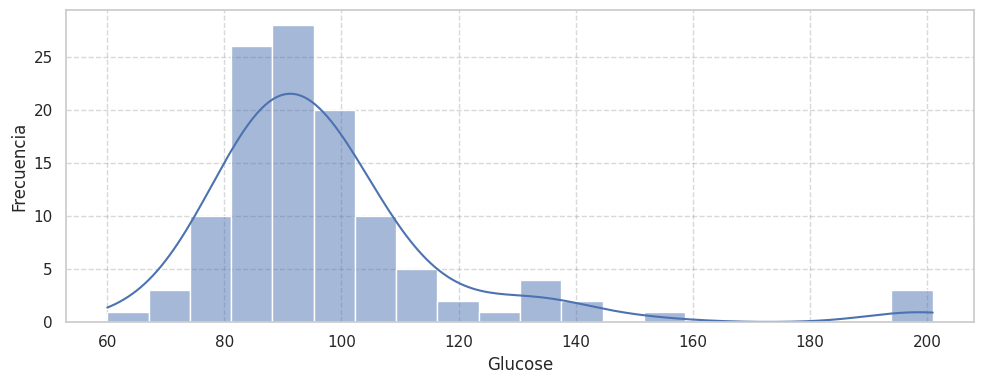

--- INSULIN ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 113

Estadísticos descriptivos:
count    116.000000
mean      10.012086
std       10.067768
min        2.432000
25%        4.359250
50%        5.924500
75%       11.189250
max       58.460000
Name: Insulin, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/Insulin.png


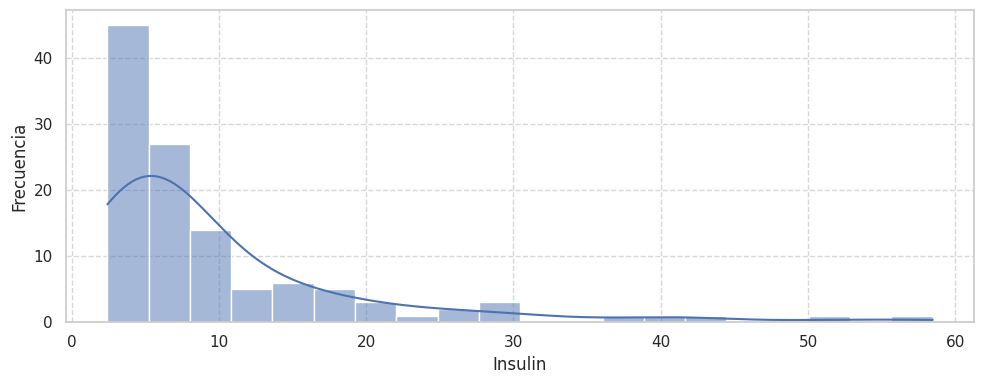

--- HOMA ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 116

Estadísticos descriptivos:
count    116.000000
mean       2.694988
std        3.642043
min        0.467409
25%        0.917966
50%        1.380939
75%        2.857787
max       25.050342
Name: HOMA, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/HOMA.png


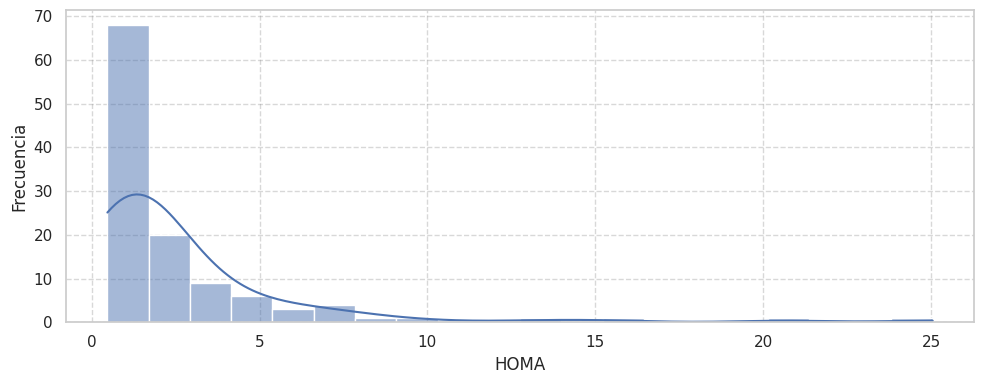

--- LEPTIN ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 116

Estadísticos descriptivos:
count    116.000000
mean      26.615080
std       19.183294
min        4.311000
25%       12.313675
50%       20.271000
75%       37.378300
max       90.280000
Name: Leptin, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/Leptin.png


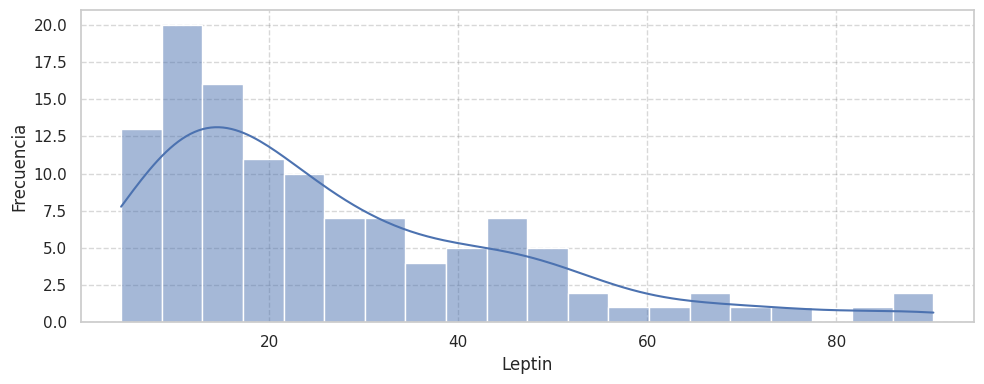

--- ADIPONECTIN ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 115

Estadísticos descriptivos:
count    116.000000
mean      10.180874
std        6.843341
min        1.656020
25%        5.474283
50%        8.352692
75%       11.815970
max       38.040000
Name: Adiponectin, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/Adiponectin.png


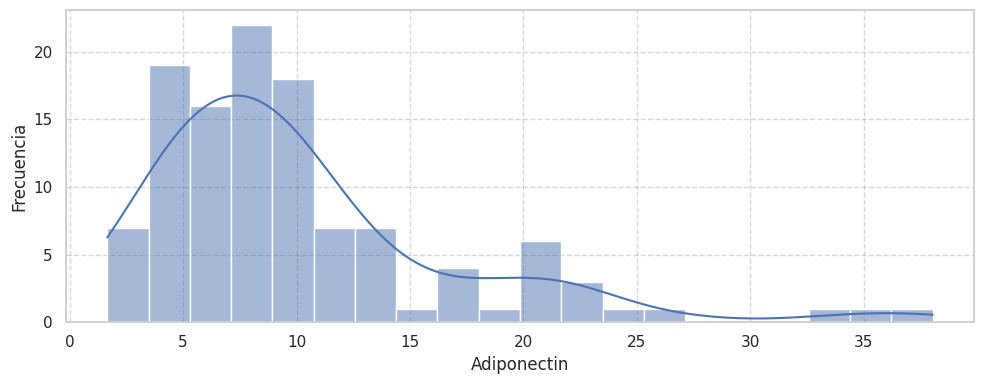

--- RESISTIN ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 116

Estadísticos descriptivos:
count    116.000000
mean      14.725966
std       12.390646
min        3.210000
25%        6.881763
50%       10.827740
75%       17.755207
max       82.100000
Name: Resistin, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/Resistin.png


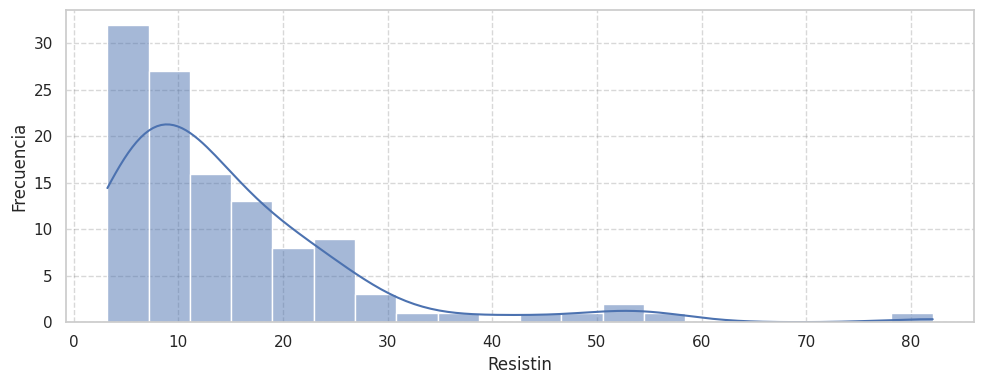

--- MCP.1 ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 113

Estadísticos descriptivos:
count     116.000000
mean      534.647000
std       345.912663
min        45.843000
25%       269.978250
50%       471.322500
75%       700.085000
max      1698.440000
Name: MCP.1, dtype: float64

Figura guardada: tfg_figuras_eda_cancer/MCP.1.png


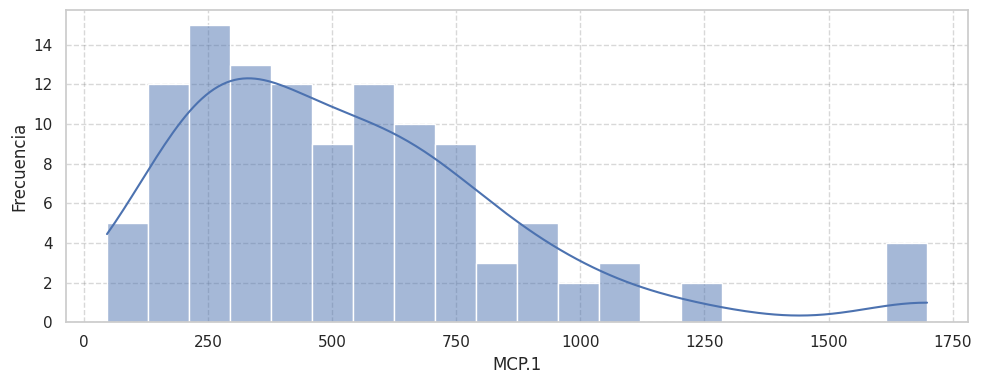

In [24]:
# Realizar EDA de las características
realizar_eda(X_cancer, "cancer")

--- CLASSIFICATION ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
Classification
2    64
1    52
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_cancer/Classification.png


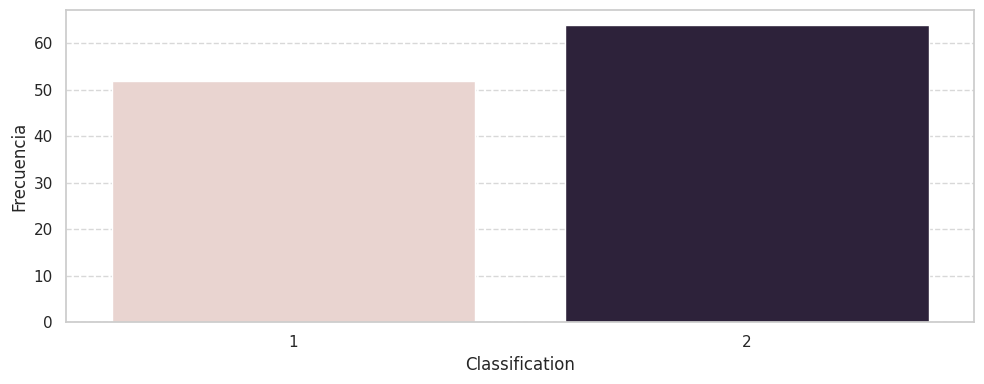

In [25]:
# Realizar EDA de la variable objetivo
realizar_eda(y_cancer, "cancer")

### Drug Induced Autoimmunity Prediction

#### Preprocesamiento

In [26]:
# Descargar el conjunto de datos desde el repositorio UCI
print("Descargando conjunto de datos...")
url = "https://archive.ics.uci.edu/static/public/1104/drug_induced_autoimmunity_prediction.zip"
respuesta = requests.get(url)

# Abrir el archivo ZIP y leer los archivos CSV
with zipfile.ZipFile(io.BytesIO(respuesta.content)) as z:
    dia_train = pd.read_csv(z.open('DIA_trainingset_RDKit_descriptors.csv'))
    dia_test = pd.read_csv(z.open('DIA_testset_RDKit_descriptors.csv'))

# Unificar los conjuntos de entrenamiento y test
dia_unificado = pd.concat([dia_train, dia_test], ignore_index=True)
print(f"Dimensiones: {dia_unificado.shape}")

Descargando conjunto de datos...
Dimensiones: (597, 198)


In [27]:
# 1. Reducción y rebalanceo del conjunto de datos

# Separar el dataframe original por clases
dia_clase_mayoritaria = dia_unificado[dia_unificado['Label'] == 0]
dia_clase_minoritaria = dia_unificado[dia_unificado['Label'] == 1]

print(f"Distribución original:")
print(f"  Clase 0: {len(dia_clase_mayoritaria)} observaciones")
print(f"  Clase 1: {len(dia_clase_minoritaria)} observaciones")

# Extraer muestras aleatorias de cada clase para alcanzar las cuotas exactas
dia_clase_mayoritaria_muestreada = dia_clase_mayoritaria.sample(
    n=NUMERO_OBSERVACIONES_CLASE_MAYORITARIA,
    random_state=SEMILLA
)
dia_clase_minoritaria_muestreada = dia_clase_minoritaria.sample(
    n=NUMERO_OBSERVACIONES_CLASE_MINORITARIA,
    random_state=SEMILLA
)

# Combinar ambos subconjuntos muestreados
dia_reducido = pd.concat([dia_clase_mayoritaria_muestreada, dia_clase_minoritaria_muestreada])

# Mezclar (shuffle) el dataframe resultante
dia_reducido = dia_reducido.sample(frac=1, random_state=SEMILLA)

# Reseteamos el índice
dia_reducido = dia_reducido.reset_index(drop=True)

print(f"\nDimensiones tras la reducción y rebalanceo: {dia_reducido.shape}")
print(f"\nDistribución de la clase objetivo tras el rebalanceo:")
print(dia_reducido['Label'].value_counts())

Distribución original:
  Clase 0: 449 observaciones
  Clase 1: 148 observaciones

Dimensiones tras la reducción y rebalanceo: (300, 198)

Distribución de la clase objetivo tras el rebalanceo:
Label
0    195
1    105
Name: count, dtype: int64


In [28]:
# 2. Separación de la clase objetivo y limpieza inicial

X_dia_reducido = dia_reducido.drop(columns=['Label'])
y_dia_reducido = dia_reducido['Label']

# Eliminar identificadores no predictivos (SMILES)
if 'SMILES' in X_dia_reducido.columns:
    X_dia_reducido = X_dia_reducido.drop(columns=['SMILES'])

# Identificar y eliminar variables casi constantes
# Definimos que si el valor más frecuente de una columna ocupa más del 90% de las observaciones, se descarta
columnas_casi_constantes = []

for col in X_dia_reducido.columns:
    # normalize=True devuelve proporciones e iloc[0] toma la proporción del valor más frecuente
    frecuencia_maxima = X_dia_reducido[col].value_counts(normalize=True, dropna=False).iloc[0]

    if frecuencia_maxima >= UMBRAL_FRECUENCIA:
        columnas_casi_constantes.append(col)

# Ejecutar la eliminación
X_dia_reducido = X_dia_reducido.drop(columns=columnas_casi_constantes)

print(f"Número de variables eliminadas: {len(columnas_casi_constantes)}")
print(f"Número de variables conservadas: {X_dia_reducido.shape[1]}")

Número de variables eliminadas: 68
Número de variables conservadas: 128


In [29]:
# 3. Selección de características con mRMR

print(f"Iniciando selección con mRMR para extraer las {NUMERO_CARACTERISTICAS} características más informativas...")

# Se aplica sobre toda la distribución (X, y) para homogeneizar
# el espacio de entrada en la comparativa posterior de modelos
columnas_seleccionadas = mrmr_classif(X=X_dia_reducido, y=y_dia_reducido, K=NUMERO_CARACTERISTICAS)

print("\nCaracterísticas seleccionadas:")
for i, col in enumerate(columnas_seleccionadas, 1):
    print(f"  {i}. {col}")

Iniciando selección con mRMR para extraer las 15 características más informativas...


100%|██████████| 15/15 [00:03<00:00,  3.82it/s]


Características seleccionadas:
  1. fr_aniline
  2. SlogP_VSA4
  3. NHOHCount
  4. MinPartialCharge
  5. fr_amide
  6. SlogP_VSA8
  7. fr_NH2
  8. PEOE_VSA8
  9. SlogP_VSA10
  10. MaxAbsPartialCharge
  11. SlogP_VSA12
  12. fr_bicyclic
  13. PEOE_VSA12
  14. fr_ether
  15. MinAbsEStateIndex


In [30]:
# 4. Construcción del dataset final y exportación

dia_final = X_dia_reducido[columnas_seleccionadas].copy()
dia_final['Label'] = y_dia_reducido.values

dia_final.to_csv('drug_induced_autoimmunity_prediction_clean.csv', index=False, encoding='utf-8')

print(f"Dimensiones del dataset final: {dia_final.shape}")

Dimensiones del dataset final: (300, 16)


#### Exploración inicial

In [31]:
# Recuperar el conjunto de datos 
drug_induced_autoimmunity_prediction = pd.read_csv('drug_induced_autoimmunity_prediction_clean.csv')

# Variables
X_dia = drug_induced_autoimmunity_prediction.drop(columns=['Label'])
y_dia = drug_induced_autoimmunity_prediction[['Label']]

In [32]:
# Mostrar las primeras filas de las características
print(X_dia.head())

   fr_aniline  SlogP_VSA4  NHOHCount  MinPartialCharge  fr_amide  SlogP_VSA8  \
0           1      16.032          1            -0.466         0       0.000   
1           1       0.000          4            -0.394         0      11.164   
2           0       5.817          3            -0.481         0      28.106   
3           1       5.817          3            -0.393         0       0.000   
4           2       0.000          8            -0.382         1       0.000   

   fr_NH2  PEOE_VSA8  SlogP_VSA10  MaxAbsPartialCharge  SlogP_VSA12  \
0       0     23.024        5.687                0.466        0.000   
1       1      6.421        5.818                0.394       11.601   
2       0     34.623        4.390                0.481        0.000   
3       1      5.753       10.208                0.393       11.762   
4       4      0.000       11.636                0.382       11.601   

   fr_bicyclic  PEOE_VSA12  fr_ether  MinAbsEStateIndex  
0            0       0.000        

In [33]:
# Mostrar las primeras filas de la variable objetivo
print(y_dia.head())

   Label
0      0
1      1
2      1
3      1
4      0


In [34]:
# Resumen de las variables
print(X_dia.describe())

       fr_aniline  SlogP_VSA4   NHOHCount  MinPartialCharge    fr_amide  \
count  300.000000  300.000000  300.000000        300.000000  300.000000   
mean     0.416667    8.100463    2.250000         -0.441810    0.576667   
std      0.724434   10.560741    2.033375          0.105883    1.042952   
min      0.000000    0.000000    0.000000         -0.873000    0.000000   
25%      0.000000    0.000000    1.000000         -0.492000    0.000000   
50%      0.000000    5.817000    2.000000         -0.459500    0.000000   
75%      1.000000   11.836000    3.000000         -0.367000    1.000000   
max      4.000000   40.420000   15.000000         -0.186000   10.000000   

       SlogP_VSA8      fr_NH2   PEOE_VSA8  SlogP_VSA10  MaxAbsPartialCharge  \
count  300.000000  300.000000  300.000000   300.000000           300.000000   
mean     3.282100    0.250000   18.564393     4.160877             0.446673   
std      6.234059    0.590476   13.805573     6.289932             0.102039   
min     

In [35]:
# Resumen de la variable objetivo
print(y_dia.describe())

            Label
count  300.000000
mean     0.350000
std      0.477767
min      0.000000
25%      0.000000
50%      0.000000
75%      1.000000
max      1.000000


#### Partición de los datos

In [36]:
# Particionar los datos
X_entrenamiento_dia, X_test_dia, y_entrenamiento_dia, y_test_dia = particionar_datos(
    X_dia, 
    y_dia, 
    seed=SEMILLA
)

print(f"Dimensiones de los conjuntos de datos:")
print(f"    X_entrenamiento_dia: {X_entrenamiento_dia.shape}")
print(f"    X_test_dia:          {X_test_dia.shape}")
print(f"    y_entrenamiento_dia: {y_entrenamiento_dia.shape}")
print(f"    y_test_dia:          {y_test_dia.shape}")

Dimensiones de los conjuntos de datos:
    X_entrenamiento_dia: (210, 15)
    X_test_dia:          (90, 15)
    y_entrenamiento_dia: (210, 1)
    y_test_dia:          (90, 1)


#### Análisis exploratorio de datos

--- FR_ANILINE ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 5

Frecuencia de valores:
fr_aniline
0    210
1     61
2     24
3      4
4      1
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_dia/fr_aniline.png


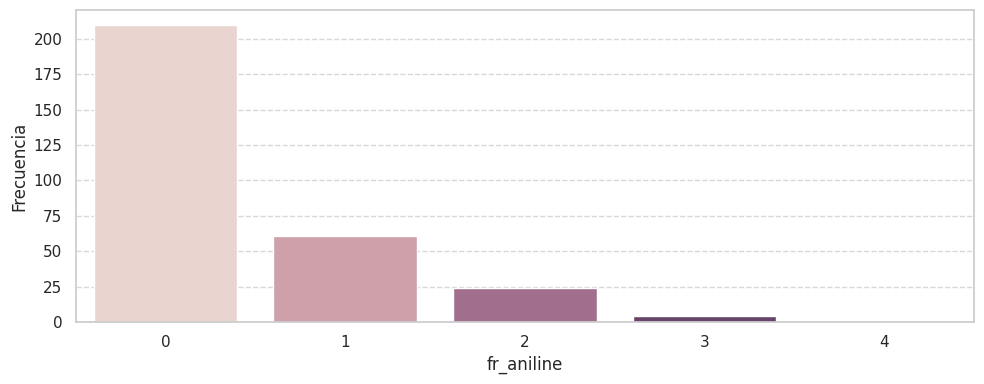

--- SLOGP_VSA4 ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 48

Estadísticos descriptivos:
count    300.000000
mean       8.100463
std       10.560741
min        0.000000
25%        0.000000
50%        5.817000
75%       11.836000
max       40.420000
Name: SlogP_VSA4, dtype: float64

Figura guardada: tfg_figuras_eda_dia/SlogP_VSA4.png


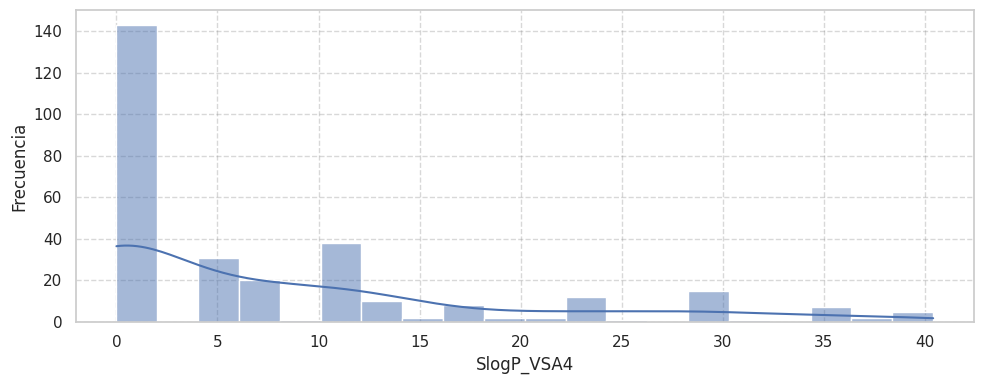

--- NHOHCOUNT ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 11

Frecuencia de valores:
NHOHCount
2     71
1     70
0     55
3     36
4     34
5     13
6      8
7      6
8      5
15     1
9      1
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_dia/NHOHCount.png


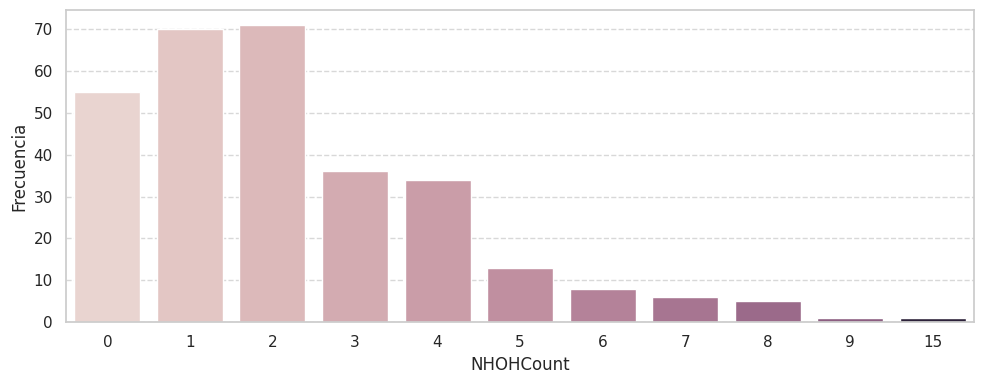

--- MINPARTIALCHARGE ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 132

Estadísticos descriptivos:
count    300.000000
mean      -0.441810
std        0.105883
min       -0.873000
25%       -0.492000
50%       -0.459500
75%       -0.367000
max       -0.186000
Name: MinPartialCharge, dtype: float64

Figura guardada: tfg_figuras_eda_dia/MinPartialCharge.png


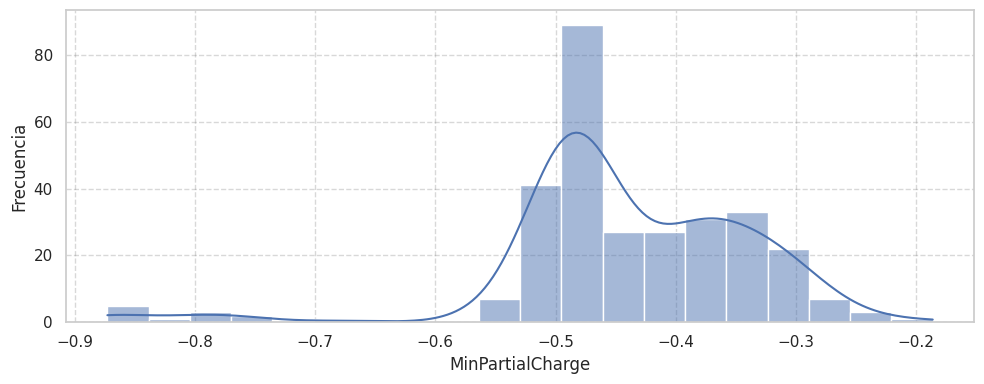

--- FR_AMIDE ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 7

Frecuencia de valores:
fr_amide
0     188
1      79
2      19
3       8
4       3
5       2
10      1
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_dia/fr_amide.png


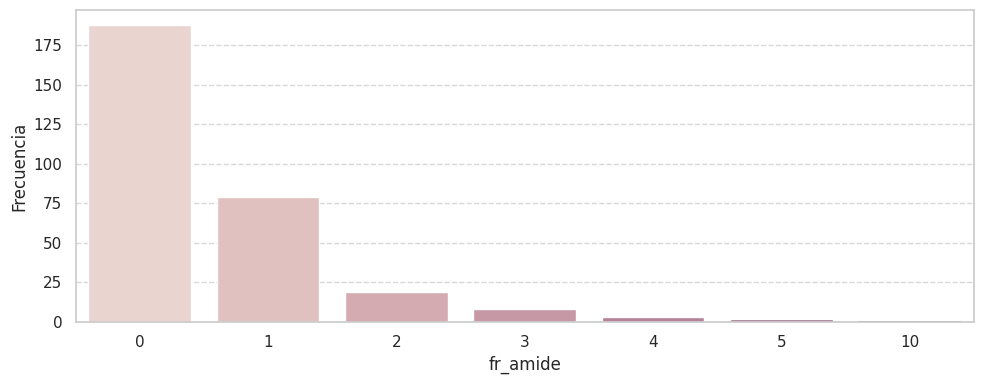

--- SLOGP_VSA8 ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 36

Estadísticos descriptivos:
count    300.000000
mean       3.282100
std        6.234059
min        0.000000
25%        0.000000
50%        0.000000
75%        5.687000
max       28.106000
Name: SlogP_VSA8, dtype: float64

Figura guardada: tfg_figuras_eda_dia/SlogP_VSA8.png


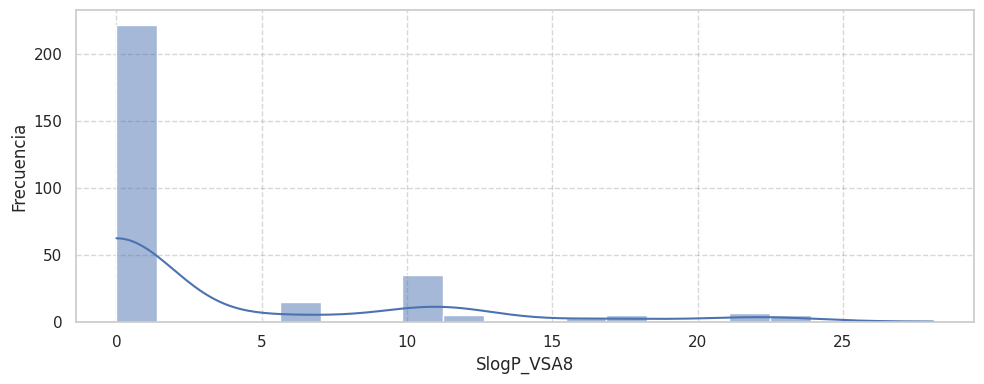

--- FR_NH2 ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 5

Frecuencia de valores:
fr_NH2
0    242
1     46
2      9
4      2
3      1
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_dia/fr_NH2.png


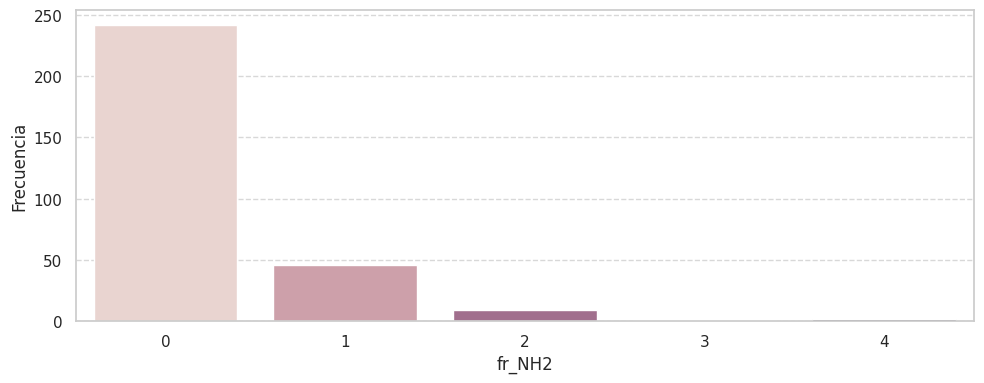

--- PEOE_VSA8 ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 199

Estadísticos descriptivos:
count    300.000000
mean      18.564393
std       13.805573
min        0.000000
25%        9.592750
50%       16.972500
75%       24.871500
max       96.854000
Name: PEOE_VSA8, dtype: float64

Figura guardada: tfg_figuras_eda_dia/PEOE_VSA8.png


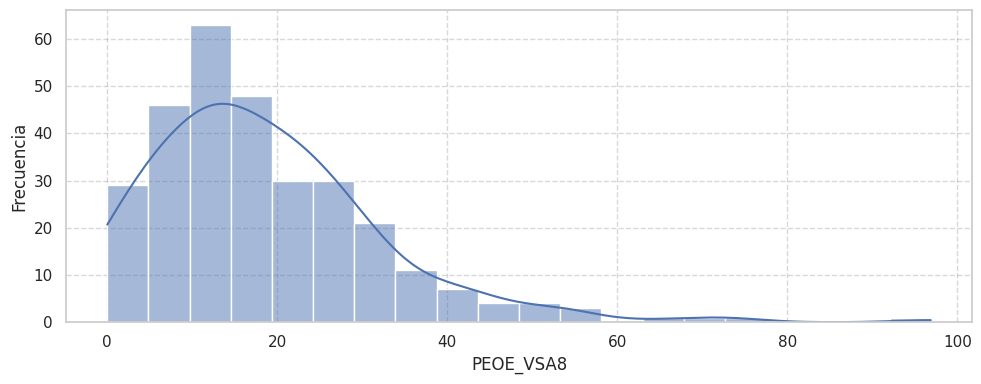

--- SLOGP_VSA10 ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 40

Estadísticos descriptivos:
count    300.000000
mean       4.160877
std        6.289932
min        0.000000
25%        0.000000
50%        0.000000
75%        5.687000
max       35.123000
Name: SlogP_VSA10, dtype: float64

Figura guardada: tfg_figuras_eda_dia/SlogP_VSA10.png


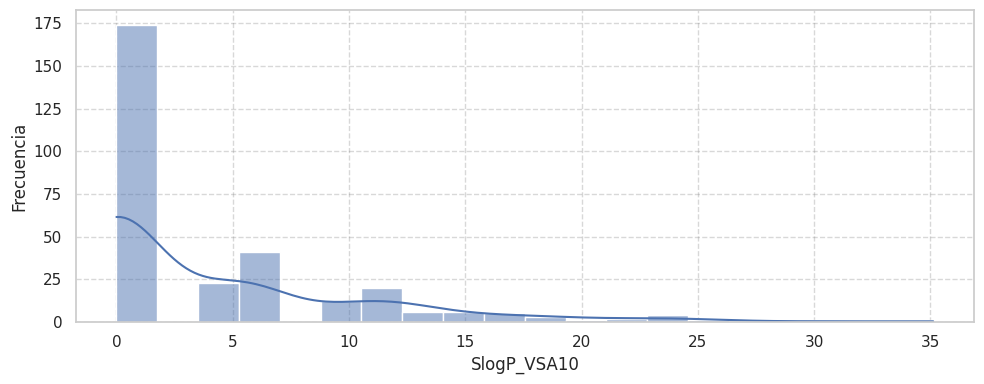

--- MAXABSPARTIALCHARGE ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 131

Estadísticos descriptivos:
count    300.000000
mean       0.446673
std        0.102039
min        0.249000
25%        0.381750
50%        0.461000
75%        0.492250
max        0.873000
Name: MaxAbsPartialCharge, dtype: float64

Figura guardada: tfg_figuras_eda_dia/MaxAbsPartialCharge.png


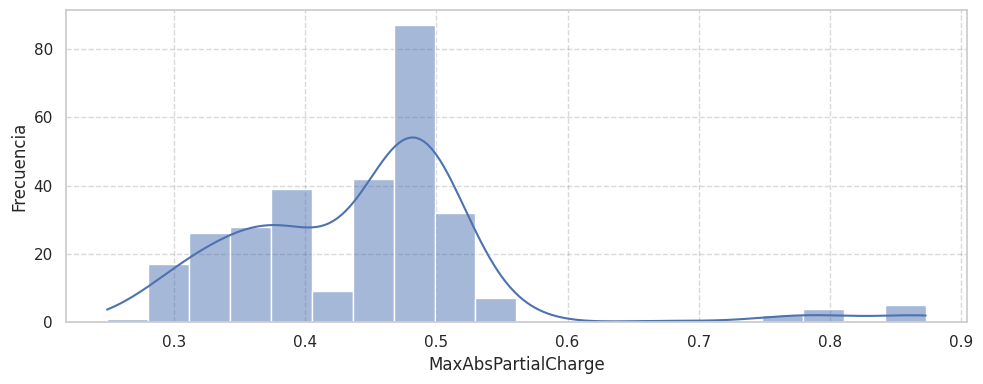

--- SLOGP_VSA12 ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 29

Estadísticos descriptivos:
count    300.000000
mean       5.513217
std       10.385841
min        0.000000
25%        0.000000
50%        0.000000
75%       11.601000
max       67.773000
Name: SlogP_VSA12, dtype: float64

Figura guardada: tfg_figuras_eda_dia/SlogP_VSA12.png


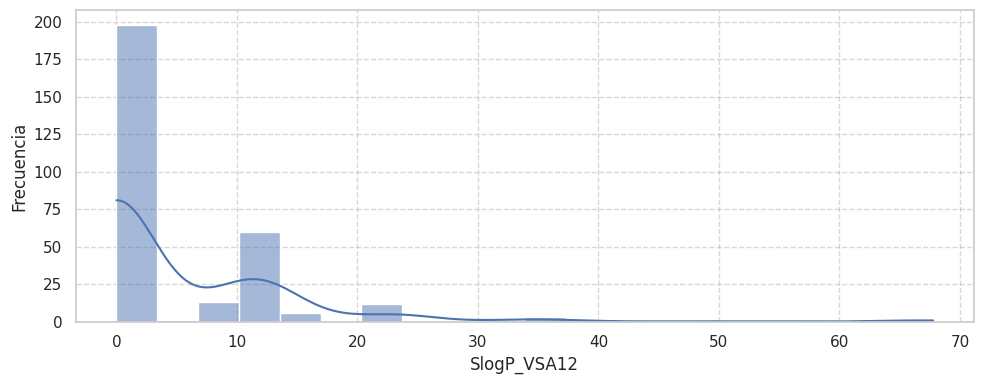

--- FR_BICYCLIC ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 8

Frecuencia de valores:
fr_bicyclic
0    152
1     78
3     21
2     19
5     16
7      8
4      3
6      3
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_dia/fr_bicyclic.png


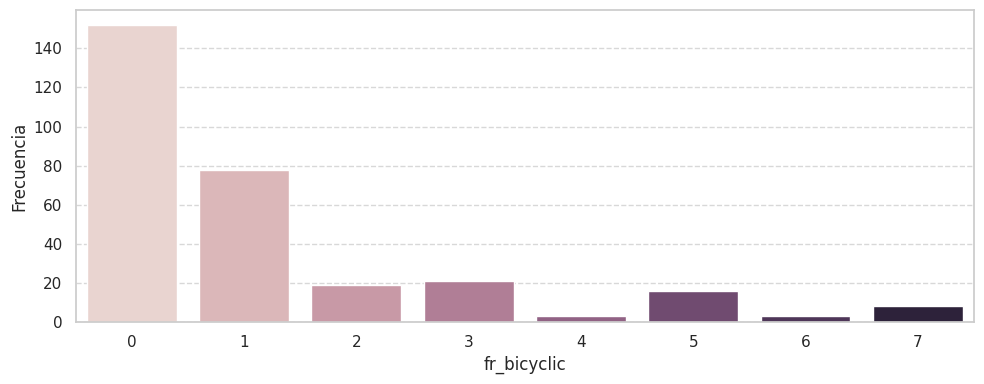

--- PEOE_VSA12 ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 44

Estadísticos descriptivos:
count    300.000000
mean       3.675650
std        6.150906
min        0.000000
25%        0.000000
50%        0.000000
75%        5.907000
max       59.072000
Name: PEOE_VSA12, dtype: float64

Figura guardada: tfg_figuras_eda_dia/PEOE_VSA12.png


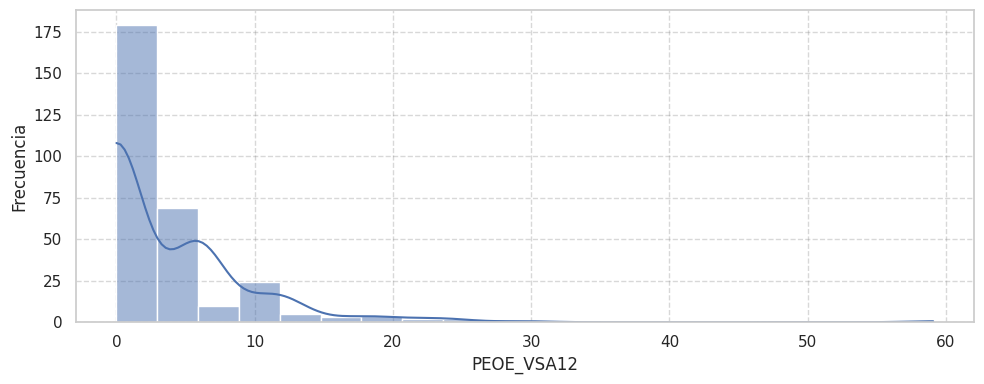

--- FR_ETHER ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 10

Frecuencia de valores:
fr_ether
0     168
1      80
2      31
3      12
4       3
7       2
5       1
10      1
6       1
9       1
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_dia/fr_ether.png


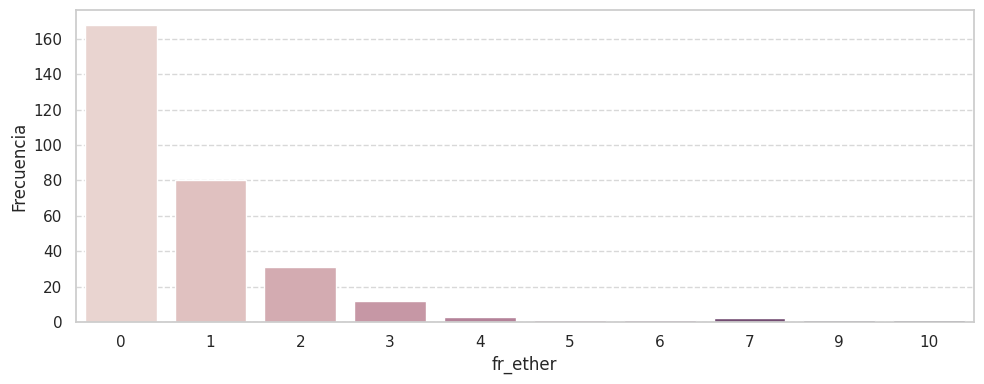

--- MINABSESTATEINDEX ---

Tipo de dato: float64
Valores nulos: 0 (0.00%)
Valores únicos: 204

Estadísticos descriptivos:
count    300.000000
mean       0.263540
std        0.654278
min        0.000000
25%        0.030750
50%        0.095500
75%        0.245250
max        6.578000
Name: MinAbsEStateIndex, dtype: float64

Figura guardada: tfg_figuras_eda_dia/MinAbsEStateIndex.png


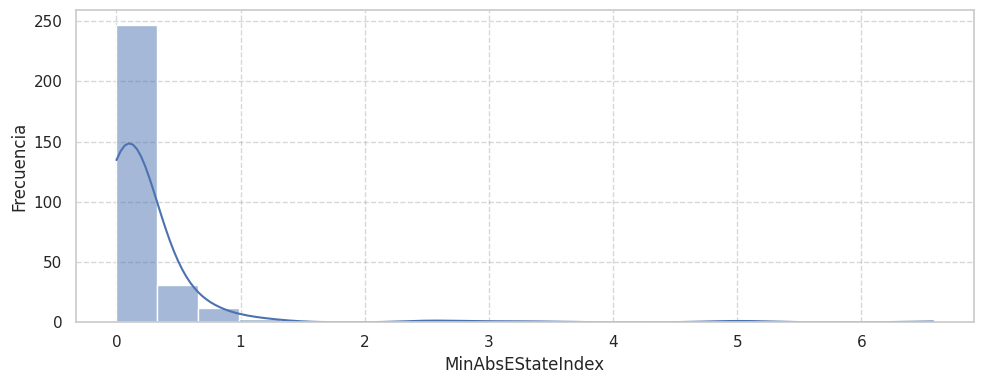

In [37]:
# Realizar EDA de las características
realizar_eda(X_dia, "dia")

--- LABEL ---

Tipo de dato: int64
Valores nulos: 0 (0.00%)
Valores únicos: 2

Frecuencia de valores:
Label
0    195
1    105
Name: count, dtype: int64

Figura guardada: tfg_figuras_eda_dia/Label.png


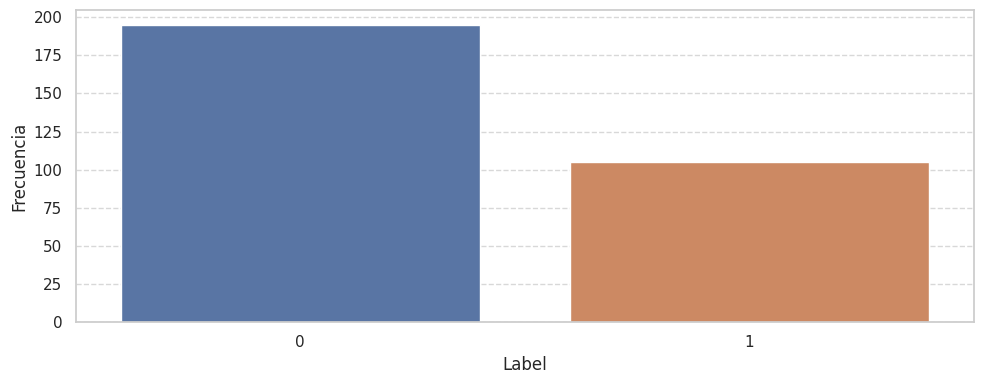

In [38]:
# Realizar EDA de la variable objetivo
realizar_eda(y_dia, "dia")

## Modelos tradicionales

In [ ]:
def calcular_metricas_modelos_tradicionales(y_real, y_pred, conjunto_nombre):
    """
    Función auxiliar para calcular métricas de rendimiento de un modelo tradicional
    """
    
    # Calculamos métricas
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, zero_division=0)
    recall = recall_score(y_real, y_pred, zero_division=0)
    f1 = f1_score(y_real, y_pred, zero_division=0)

    print(f"\n--- Rendimiento en el conjunto de {conjunto_nombre} ---")
    print(f"    Accuracy:  {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall:    {recall:.4f}")
    print(f"    F1-score:  {f1:.4f}")

    metricas = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    
    return metricas

### Árbol de decisión

In [ ]:
def arbol_decision(X, y, nombre_dataset):
    """
    Realiza la predicción utilizando árbol de decisión con búsqueda de hiperparámetros
    """
    
    print(f"{'='*20} ÁRBOL DE DECISIÓN: {nombre_dataset} {'='*20}")
    
    resultados_metricas = []
    tiempos_entrenamiento = []
    tiempos_inferencia = []

    for semilla in SEMILLAS:
        print(f"\n>>> Semilla: {semilla}")
        
        # 1. Particionamiento de datos
        X_train, X_test, y_train, y_test = particionar_datos(X, y, seed=semilla)
        
        # 2. Definición del espacio de hiperparámetros para GridSearchCV
        param_grid = {
            'criterion': ['gini', 'entropy', 'log_loss'], # Criterios de calidad de división
            'splitter': ['best', 'random'],               # Estrategia de división
            'max_depth': [None, 3, 5, 7, 10, 15, 20],     # Control de profundidad
            'min_samples_split': [2, 5, 10, 20],          # Muestras para dividir
            'min_samples_leaf': [1, 2, 4, 8],             # Muestras en hojas
            'max_features': [None, 'sqrt', 'log2'],       # Características a considerar
            'class_weight': [None, 'balanced']            # Control del desbalanceo de clases
        }

        # 3. Configuración de GridSearchCV
        clasificador_arbol_decision = DecisionTreeClassifier(random_state=semilla)

        # Validación cruzada estratificada para mantener la proporción de clases en cada fold
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

        grid_search = GridSearchCV(
            estimator=clasificador_arbol_decision,
            param_grid=param_grid,
            cv=stratified_kfold,    # Validación cruzada estratificada
            scoring='f1',           # Optimizamos F1
            n_jobs=-1,              # Paralelización
            verbose=0               # No mostrar logs
        )

        print("    Iniciando búsqueda de hiperparámetros...")

        # --- Tiempo de entrenamiento ---
        start_entrenamiento = time.time()

        # Ejecutar GridSearchCV encontrando el mejor modelo y los mejores hiperparámetros
        # en el conjunto de entrenamiento
        grid_search.fit(X_train, y_train)

        # Extracción del mejor modelo
        best_model = grid_search.best_estimator_

        end_entrenamiento = time.time()
        duracion_entrenamiento = end_entrenamiento - start_entrenamiento
        tiempos_entrenamiento.append(duracion_entrenamiento)

        print(f"    Mejores hiperparámetros: {grid_search.best_params_}")
        print(f"    Mejor score (CV): {grid_search.best_score_:.4f}")

        # 4. Evaluación del rendimiento
        
        # Predicción y evaluación en entrenamiento
        y_train_pred = best_model.predict(X_train)
        calcular_metricas_modelos_tradicionales(y_train, y_train_pred, "entrenamiento")

        # --- Tiempo de inferencia ---
        start_inferencia = time.time()
        
        y_test_pred = best_model.predict(X_test)

        end_inferencia = time.time()
        duracion_inferencia = end_inferencia - start_inferencia
        tiempos_inferencia.append(duracion_inferencia)

        # Evaluación en test
        metricas_test = calcular_metricas_modelos_tradicionales(y_test, y_test_pred, "test")

        # 5. Visualización de la matriz de confusión (test)
        matriz_confusion = confusion_matrix(y_test, y_test_pred)
        print(f"\n    Matriz de confusión:")
        if matriz_confusion.shape == (2, 2):
            print(f"    [TN: {matriz_confusion[0][0]}, FP: {matriz_confusion[0][1]}]")
            print(f"    [FN: {matriz_confusion[1][0]}, TP: {matriz_confusion[1][1]}]")

        # Guardar las métricas del test
        resultados_metricas.append(metricas_test)

        print(f"\n    Tiempo entrenamiento: {duracion_entrenamiento:.4f} s")
        print(f"    Tiempo inferencia: {duracion_inferencia:.4f} s")

    return resultados_metricas, tiempos_entrenamiento, tiempos_inferencia

In [ ]:
resultados_metricas_dt_heart, tiempos_entrenamiento_dt_heart, tiempos_inferencia_dt_heart = arbol_decision(X_heart, y_heart, nombre_dataset="Heart Failure Clinical Records")

In [ ]:
resultados_metricas_dt_cancer, tiempos_entrenamiento_dt_cancer, tiempos_inferencia_dt_cancer = arbol_decision(X_cancer, y_cancer, nombre_dataset="Breast Cancer Coimbra")

In [ ]:
resultados_metricas_dt_dia, tiempos_entrenamiento_dt_dia, tiempos_inferencia_dt_dia = arbol_decision(X_dia, y_dia, nombre_dataset="Drug Induced Autoimmunity Prediction")

### Random forest

In [ ]:
def random_forest(X, y, nombre_dataset):
    """
    Realiza la predicción utilizando Random Forest con búsqueda de hiperparámetros
    """
    
    print(f"{'='*20} RANDOM FOREST: {nombre_dataset} {'='*20}")
    
    resultados_metricas = []
    tiempos_entrenamiento = []
    tiempos_inferencia = []

    for semilla in SEMILLAS:
        print(f"\n>>> Semilla: {semilla}")
        
        # 1. Particionamiento de datos
        X_train, X_test, y_train, y_test = particionar_datos(X, y, seed=semilla)

        # RandomForest requiere que y sea un array 1D
        y_train = y_train.values.ravel() 
        y_test = y_test.values.ravel()    
        
        # 2. Definición del espacio de hiperparámetros para GridSearchCV
        param_grid = {
            'n_estimators': [50, 100, 200, 300],          # Número de árboles
            'criterion': ['gini', 'entropy', 'log_loss'], # Criterios de calidad de división
            'max_depth': [None, 5, 10, 15, 20],           # Control de profundidad
            'min_samples_split': [2, 5, 10, 20],          # Muestras para dividir
            'min_samples_leaf': [1, 2, 4, 8],             # Muestras en hojas
            'max_features': [None, 'sqrt', 'log2'],       # Características a considerar
            'bootstrap': [True, False],                   # Muestreo con reemplazo
            'class_weight': [None, 'balanced']            # Control del desbalanceo de clases
        }

        # 3. Configuración de GridSearchCV
        clasificador_random_forest = RandomForestClassifier(random_state=semilla)

        # Validación cruzada estratificada para mantener la proporción de clases en cada fold
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

        grid_search = GridSearchCV(
            estimator=clasificador_random_forest,
            param_grid=param_grid,
            cv=stratified_kfold,    # Validación cruzada estratificada
            scoring='f1',           # Optimizamos F1
            n_jobs=-1,              # Paralelización
            verbose=0               # No mostrar logs
        )

        print("    Iniciando búsqueda de hiperparámetros...")

        # --- Tiempo de entrenamiento ---
        start_entrenamiento = time.time()
        
        # Ejecutar GridSearchCV encontrando el mejor modelo y los mejores hiperparámetros
        # en el conjunto de entrenamiento
        grid_search.fit(X_train, y_train)
        
        # Extracción del mejor modelo
        best_model = grid_search.best_estimator_

        end_entrenamiento = time.time()
        duracion_entrenamiento = end_entrenamiento - start_entrenamiento
        tiempos_entrenamiento.append(duracion_entrenamiento)

        print(f"    Mejores hiperparámetros: {grid_search.best_params_}")
        print(f"    Mejor score (CV): {grid_search.best_score_:.4f}")

        # 4. Evaluación del rendimiento
        
        # Predicción y evaluación en entrenamiento
        y_train_pred = best_model.predict(X_train)
        calcular_metricas_modelos_tradicionales(y_train, y_train_pred, "entrenamiento")

        # --- Tiempo de inferencia ---
        start_inferencia = time.time()
        
        y_test_pred = best_model.predict(X_test)
        
        end_inferencia = time.time()
        duracion_inferencia = end_inferencia - start_inferencia
        tiempos_inferencia.append(duracion_inferencia)

        # Evaluación en test
        metricas_test = calcular_metricas_modelos_tradicionales(y_test, y_test_pred, "test")

        # 5. Visualización de la matriz de confusión (test)
        matriz_confusion = confusion_matrix(y_test, y_test_pred)
        print(f"\n    Matriz de confusión:")
        if matriz_confusion.shape == (2, 2):
            print(f"    [TN: {matriz_confusion[0][0]}, FP: {matriz_confusion[0][1]}]")
            print(f"    [FN: {matriz_confusion[1][0]}, TP: {matriz_confusion[1][1]}]")

        # Guardar las métricas del test
        resultados_metricas.append(metricas_test)

        print(f"\n    Tiempo entrenamiento: {duracion_entrenamiento:.4f} s")
        print(f"    Tiempo inferencia: {duracion_inferencia:.6f} s")

    return resultados_metricas, tiempos_entrenamiento, tiempos_inferencia

In [ ]:
resultados_metricas_rf_heart, tiempos_entrenamiento_rf_heart, tiempos_inferencia_rf_heart = random_forest(X_heart, y_heart, nombre_dataset="Heart Failure Clinical Records")

In [ ]:
resultados_metricas_rf_cancer, tiempos_entrenamiento_rf_cancer, tiempos_inferencia_rf_cancer = random_forest(X_cancer, y_cancer, nombre_dataset="Breast Cancer Coimbra")

In [ ]:
resultados_metricas_rf_dia, tiempos_entrenamiento_rf_dia, tiempos_inferencia_rf_dia = random_forest(X_dia, y_dia, nombre_dataset="Drug Induced Autoimmunity Prediction")

### XGBoost

In [ ]:
def xgboost(X, y, nombre_dataset):
    """
    Realiza la predicción utilizando XGBoost con búsqueda de hiperparámetros
    """
    
    print(f"{'='*20} XGBOOST: {nombre_dataset} {'='*20}")
    
    resultados_metricas = []
    tiempos_entrenamiento = []
    tiempos_inferencia = []

    for semilla in SEMILLAS:
        print(f"\n>>> Semilla: {semilla}")
        
        # 1. Particionamiento de datos
        X_train, X_test, y_train, y_test = particionar_datos(X, y, seed=semilla)
        
        # Convertir y a array 1D para XGBoost
        y_train = y_train.values.ravel()
        y_test = y_test.values.ravel()

        # Codificar etiquetas para XGBoost
        label_encoder = LabelEncoder()
        y_train = label_encoder.fit_transform(y_train)
        y_test = label_encoder.transform(y_test)
        
        # 2. Definición del espacio de hiperparámetros para GridSearchCV
        param_grid = {
            'n_estimators': [100, 200, 300],    # Número de árboles
            'max_depth': [3, 5, 7, 10],         # Control de profundidad
            'learning_rate': [0.01, 0.1, 0.3],  # Tasa de aprendizaje
            'subsample': [0.8, 1.0],            # Proporción de muestras
            'colsample_bytree': [0.8, 1.0],     # Proporción de características
            'min_child_weight': [1, 3, 5],      # Peso mínimo en nodos hijos
            'gamma': [0, 0.1, 0.2],             # Reducción mínima de pérdida
            'reg_alpha': [0, 0.1, 0.5],         # Regularización L1
            'reg_lambda': [1, 1.5, 2]           # Regularización L2
        }

        # 3. Configuración de GridSearchCV
        clasificador_xgboost = XGBClassifier(random_state=semilla)

        # Validación cruzada estratificada para mantener la proporción de clases en cada fold
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

        grid_search = GridSearchCV(
            estimator=clasificador_xgboost,
            param_grid=param_grid,
            cv=stratified_kfold,    # Validación cruzada estratificada
            scoring='f1',           # Optimizamos F1
            n_jobs=-1,              # Paralelización
            verbose=0               # No mostrar logs
        )

        print("    Iniciando búsqueda de hiperparámetros...")

        # --- Tiempo de entrenamiento ---
        start_entrenamiento = time.time()

        # Ejecutar GridSearchCV encontrando el mejor modelo y los mejores hiperparámetros
        # en el conjunto de entrenamiento
        grid_search.fit(X_train, y_train)

        # Extracción del mejor modelo
        best_model = grid_search.best_estimator_

        end_entrenamiento = time.time()
        duracion_entrenamiento = end_entrenamiento - start_entrenamiento
        tiempos_entrenamiento.append(duracion_entrenamiento)

        print(f"    Mejores hiperparámetros: {grid_search.best_params_}")
        print(f"    Mejor score (CV): {grid_search.best_score_:.4f}")

        # 4. Evaluación del rendimiento
        
        # Predicción y evaluación en entrenamiento
        y_train_pred = best_model.predict(X_train)
        calcular_metricas_modelos_tradicionales(y_train, y_train_pred, "entrenamiento")

        # --- Tiempo de inferencia ---
        start_inferencia = time.time()
        
        y_test_pred = best_model.predict(X_test)
        
        end_inferencia = time.time()
        duracion_inferencia = end_inferencia - start_inferencia
        tiempos_inferencia.append(duracion_inferencia)

        # Evaluación en test
        metricas_test = calcular_metricas_modelos_tradicionales(y_test, y_test_pred, "test")

        # 5. Visualización de la matriz de confusión (test)
        matriz_confusion = confusion_matrix(y_test, y_test_pred)
        print(f"\n    Matriz de confusión:")
        if matriz_confusion.shape == (2, 2):
            print(f"    [TN: {matriz_confusion[0][0]}, FP: {matriz_confusion[0][1]}]")
            print(f"    [FN: {matriz_confusion[1][0]}, TP: {matriz_confusion[1][1]}]")

        # Guardar las métricas del test
        resultados_metricas.append(metricas_test)

        print(f"\n    Tiempo entrenamiento: {duracion_entrenamiento:.4f} s")
        print(f"    Tiempo inferencia: {duracion_inferencia:.6f} s")

    return resultados_metricas, tiempos_entrenamiento, tiempos_inferencia

In [ ]:
resultados_metricas_xgb_heart, tiempos_entrenamiento_xgb_heart, tiempos_inferencia_xgb_heart = xgboost(X_heart, y_heart, nombre_dataset="Heart Failure Clinical Records")

In [ ]:
resultados_metricas_xgb_cancer, tiempos_entrenamiento_xgb_cancer, tiempos_inferencia_xgb_cancer = xgboost(X_cancer, y_cancer, nombre_dataset="Breast Cancer Coimbra")

In [ ]:
resultados_metricas_xgb_dia, tiempos_entrenamiento_xgb_dia, tiempos_inferencia_xgb_dia = xgboost(X_dia, y_dia, nombre_dataset="Drug Induced Autoimmunity Prediction")

### Resultados

In [ ]:
# 1. Agrupar todas las variables en una estructura iterable
ejecuciones_modelos_tradicionales = [
    # Heart Failure Clinical Records
    ("Heart", "Árbol de decisión", resultados_metricas_dt_heart, tiempos_entrenamiento_dt_heart, tiempos_inferencia_dt_heart),
    ("Heart", "Random Forest", resultados_metricas_rf_heart, tiempos_entrenamiento_rf_heart, tiempos_inferencia_rf_heart),
    ("Heart", "XGBoost", resultados_metricas_xgb_heart, tiempos_entrenamiento_xgb_heart, tiempos_inferencia_xgb_heart),
    
    # Breast Cancer Coimbra
    ("Cancer", "Árbol de decisión", resultados_metricas_dt_cancer, tiempos_entrenamiento_dt_cancer, tiempos_inferencia_dt_cancer),
    ("Cancer", "Random Forest", resultados_metricas_rf_cancer, tiempos_entrenamiento_rf_cancer, tiempos_inferencia_rf_cancer),
    ("Cancer", "XGBoost", resultados_metricas_xgb_cancer, tiempos_entrenamiento_xgb_cancer, tiempos_inferencia_xgb_cancer),
    
    # Drug Induced Autoimmunity Prediction
    ("DIA", "Árbol de decisión", resultados_metricas_dt_dia, tiempos_entrenamiento_dt_dia, tiempos_inferencia_dt_dia),
    ("DIA", "Random Forest", resultados_metricas_rf_dia, tiempos_entrenamiento_rf_dia, tiempos_inferencia_rf_dia),
    ("DIA", "XGBoost", resultados_metricas_xgb_dia, tiempos_entrenamiento_xgb_dia, tiempos_inferencia_xgb_dia)
]

# 2. Desempaquetar los datos por semilla
filas_df_modelos_tradicionales = []

for dataset, modelo, metricas_lista, t_entrenamiento_lista, t_inferencia_lista in ejecuciones_modelos_tradicionales:
    for i in range(len(metricas_lista)): # Iterar sobre las 3 semillas
        fila = {
            "Dataset": dataset,
            "Modelo": modelo,
            "Semilla": SEMILLAS[i],
            "Tiempo entrenamiento (s)": t_entrenamiento_lista[i],
            "Tiempo inferencia (s)": t_inferencia_lista[i],
            "Accuracy": metricas_lista[i]['accuracy'],
            "Precision": metricas_lista[i]['precision'],
            "Recall": metricas_lista[i]['recall'],
            "F1-score": metricas_lista[i]['f1_score']
        }
        filas_df_modelos_tradicionales.append(fila)

# 3. Crear el DataFrame final
df_resultados_modelos_tradicionales = pd.DataFrame(filas_df_modelos_tradicionales)

# 4. Exportar a csv
df_resultados_modelos_tradicionales.to_csv("resultados_modelos_tradicionales.csv", index=False)

# Mostrar la tabla de resultados
print("--- Resultados modelos tradicionales ---\n")
print(df_resultados_modelos_tradicionales.head())

## Large Language Models

### Preprocesamiento

#### Mapeo semántico

In [ ]:
def mapear_semanticamente_heart(X, y):
    """
    Mapea los valores binarios (0, 1) a texto descriptivo del conjunto de datos Heart Failure Clinical Records
    """

    # 1. Definición de mapeos semánticos

    mapeo_si_no = {
      0: 'no',
      1: 'yes'
    }

    mapeo_sexo = {
      0: 'women',
      1: 'men'
    }

    columnas_booleanas = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

    # 2. Aplicación de mapeos a las características

    X_mapeado = X.copy()

    # Convertir las columnas a tipo 'object' 
    for col in columnas_booleanas:
        X_mapeado[col] = X_mapeado[col].astype(object)
        
    X_mapeado['sex'] = X_mapeado['sex'].astype(object)

    # Aplicar los mapeos
    for col in columnas_booleanas:
        X_mapeado[col] = X_mapeado[col].replace(mapeo_si_no)

    X_mapeado['sex'] = X_mapeado['sex'].replace(mapeo_sexo)

    # 3. Aplicación de mapeo a la variable objetivo

    y_mapeado = y.copy()
    y_mapeado['death_event'] = y_mapeado['death_event'].astype(object)
    y_mapeado['death_event'] = y_mapeado['death_event'].replace(mapeo_si_no)

    return X_mapeado, y_mapeado

In [ ]:
def mapear_semanticamente_cancer(X, y):
    """
    Mapea los valores de la variable objetivo a texto descriptivo del conjunto de datos Breast Cancer Coimbra
    """

    # 1. Definición de mapeos semánticos
    
    mapeo_clasificacion = {
        1: 'no',
        2: 'yes'
    }
    
    # 2. Las características no requieren mapeo semántico (todas son continuas)
    X_mapeado = X.copy()
    
    # 3. Aplicación de mapeo a la variable objetivo
    
    y_mapeado = y.copy()
    y_mapeado['Classification'] = y_mapeado['Classification'].astype(object)
    y_mapeado['Classification'] = y_mapeado['Classification'].replace(mapeo_clasificacion)

    return X_mapeado, y_mapeado

In [ ]:
def mapear_semanticamente_dia(X, y):
    """
    Mapea los valores de la variable objetivo a texto descriptivo del conjunto de datos Drug Induced Autoimmunity Prediction
    """

    # 1. Definición de mapeos semánticos para el target
    mapeo_etiqueta = {
        0: 'no',
        1: 'yes'
    }

    # 2. Las características no requieren mapeo semántico ya que representan conteos de fragmentos moleculares o propiedades continuas
    X_mapeado = X.copy()

    # 3. Aplicación de mapeo a la variable objetivo
    y_mapeado = y.copy()
    y_mapeado['Label'] = y_mapeado['Label'].astype(object)
    y_mapeado['Label'] = y_mapeado['Label'].replace(mapeo_etiqueta)

    return X_mapeado, y_mapeado

#### Normalización de nombres

In [ ]:
def normalizar_nombres_heart(X, y):
    """
    Normaliza los nombres de las columnas para convertirlas a frases legibles del conjunto de datos Heart Failure Clinical Records
    """
    
    # 1. Definición de normalización de nombres
    
    normalizacion_nombres = {
      'age': 'age',
      'anaemia': 'anaemia',
      'creatinine_phosphokinase': 'CPK enzyme level',
      'diabetes': 'diabetes',
      'ejection_fraction': 'ejection fraction',
      'high_blood_pressure': 'high blood pressure',
      'platelets': 'platelets count',
      'serum_creatinine': 'serum creatinine level',
      'serum_sodium': 'serum sodium level',
      'sex': 'sex',
      'smoking': 'smoking',
      'time': 'follow-up period'
    }
    
    # 2. Aplicación de la normalización de nombres
    
    # Renombrar columnas de las características
    X_normalizado = X.rename(columns=normalizacion_nombres)
    
    # Renombrar columna de la variable objetivo
    y_normalizado = y.rename(columns={'death_event': 'Death event'})
    
    return X_normalizado, y_normalizado

In [ ]:
def normalizar_nombres_cancer(X, y):
    """
    Normaliza los nombres de las columnas para convertirlas a frases legibles del conjunto de datos Breast Cancer Coimbra
    """
    
    # 1. Definición de normalización de nombres
    
    normalizacion_nombres = {
        'Age': 'age',
        'BMI': 'body mass index',
        'Glucose': 'glucose level',
        'Insulin': 'insulin level',
        'HOMA': 'homeostasis model assessment',
        'Leptin': 'leptin level',
        'Adiponectin': 'adiponectin level',
        'Resistin': 'resistin level',
        'MCP.1': 'monocyte chemoattractant protein-1'
    }
    
    # 2. Aplicación de la normalización de nombres
    
    # Renombrar columnas de las características
    X_normalizado = X.rename(columns=normalizacion_nombres)
    
    # Renombrar columna de la variable objetivo
    y_normalizado = y.rename(columns={'Classification': 'Breast cancer'})
    
    return X_normalizado, y_normalizado

In [ ]:
def normalizar_nombres_dia(X, y):
    """
    Normaliza los nombres de las columnas para convertirlas a frases legibles del conjunto de datos Drug Induced Autoimmunity Prediction
    """

    # 1. Definición de normalización de nombres de descriptores RDKit
    normalizacion_nombres = {
        'fr_aniline': 'number of anilines',
        'SlogP_VSA4': 'MOE logP VSA Descriptor 4',
        'NHOHCount': 'number of NH or OH groups',
        'MinPartialCharge': 'minimum partial charge',
        'fr_amide': 'number of amides',
        'SlogP_VSA8': 'MOE logP VSA Descriptor 8',
        'fr_NH2': 'number of primary amines',
        'PEOE_VSA8': 'MOE Charge VSA Descriptor 8',
        'SlogP_VSA10': 'MOE logP VSA Descriptor 10',
        'MaxAbsPartialCharge': 'maximum absolute partial charge',
        'SlogP_VSA12': 'MOE logP VSA Descriptor 12',
        'fr_bicyclic': 'number of bicyclic rings',
        'PEOE_VSA12': 'MOE Charge VSA Descriptor 12',
        'fr_ether': 'number of ether oxygens (including phenoxy)',
        'MinAbsEStateIndex': 'minimum absolute EState index'
    }

    # 2. Aplicación de la normalización de nombres
    
    # Renombrar columnas de las características
    X_normalizado = X.rename(columns=normalizacion_nombres)

    # Renombrar columna de la variable objetivo
    y_normalizado = y.rename(columns={'Label': 'Drug induced autoimmunity'})

    return X_normalizado, y_normalizado

### Serializaciones

In [ ]:
def formatear_valor(valor):
    """
    Formatea un valor numérico, redondea a 2 decimales y elimina .0 innecesarios
    """

    if isinstance(valor, (int, float)):
        valor = round(valor, 2)
        # Si es un entero exacto, mostrarlo sin decimales
        if valor == int(valor):
            return str(int(valor))
        
        return str(valor)
    
    return str(valor)

#### List template

In [ ]:
def serializar_list_template(X):
    """
    Serializa un DataFrame de características a formato list template
    """
    
    def serializar_fila(fila):
        """
        Convierte una fila del DataFrame en una lista de pares 'Característica: Valor' 
        """
        segmentos = []
        for nombre_caracteristica, valor in fila.items():

            # Formatear el nombre de la característica para mejorar la legibilidad
            nombre_formateado = nombre_caracteristica[0].upper() + nombre_caracteristica[1:]

            # Formatear el valor para mejorar la legibilidad
            valor_formateado = formatear_valor(valor)
            
            segmento = f"- {nombre_formateado}: {valor_formateado}"
            segmentos.append(segmento)
        return "\n".join(segmentos)

    X_serializado = X.copy()

    # Aplicar la función de serialización a cada fila del DataFrame
    X_serializado['List template serialization'] = X_serializado.apply(serializar_fila, axis=1)
    
    return X_serializado

#### Text template

In [ ]:
def serializar_text_template(X):
    """
    Serializa un DataFrame de características a formato text template
    """

    def serializar_fila(fila):
        """
        Convierte una fila del DataFrame en una frase concatenando las características y sus valores
        """
        segmentos = []
        for nombre_caracteristica, valor in fila.items():

            # Formatear el valor para mejorar la legibilidad
            valor_formateado = formatear_valor(valor)

            segmento = f"The {nombre_caracteristica} is {valor_formateado}."
            segmentos.append(segmento)
        return " ".join(segmentos)

    X_serializado = X.copy()

    # Aplicar la función de serialización a cada fila del DataFrame
    X_serializado['Text template serialization'] = X_serializado.apply(serializar_fila, axis=1)

    return X_serializado

### Prompt templates

#### Zero-shot

In [ ]:
def prompt_zero_shot_heart(paciente_serializado):
    """
    Construye el prompt de inferencia zero-shot para el conjunto de datos Heart Failure Clinical Records
    """
    prompt = f"""You are an expert cardiologist assistant specializing in heart failure risk assessment.

Please carefully review the following patient clinical record containing demographic and laboratory data:

{paciente_serializado}

Based on the clinical data provided above, predict patient mortality (Death event).

You must strictly adhere to the following constraints:
- Do not provide any other output text, explanation, or clinical reasoning.
- Output ONLY a valid JSON object.
- The JSON object must contain exactly one key named "Death event".
- The value for "Death event" must be a string: either "yes" (if mortality is predicted) or "no" (if survival is predicted).

Output:"""

    return prompt

In [ ]:
def prompt_zero_shot_cancer(paciente_serializado):
    """
    Construye el prompt de inferencia zero-shot para el conjunto de datos Breast Cancer Coimbra
    """
    prompt = f"""You are an expert oncologist assistant specializing in breast cancer risk assessment.

Please carefully review the following patient clinical record containing demographic and laboratory data:

{paciente_serializado}

Based on the clinical data provided above, predict the presence of breast cancer (Breast cancer).

You must strictly adhere to the following constraints:
- Do not provide any other output text, explanation, or clinical reasoning.
- Output ONLY a valid JSON object.
- The JSON object must contain exactly one key named "Breast cancer".
- The value for "Breast cancer" must be a string: either "yes" (if breast cancer is predicted) or "no" (if no breast cancer is predicted).

Output:"""

    return prompt

In [ ]:
def prompt_zero_shot_dia(farmaco_serializado):
    """
    Construye el prompt de inferencia zero-shot para el conjunto de datos Drug Induced Autoimmunity Prediction
    """
    prompt = f"""You are an expert chemoinformatician and computational toxicologist specializing in drug safety and adverse event prediction.

Please carefully review the following molecular profile containing RDKit structural and physicochemical descriptors:

{farmaco_serializado}

Based on the molecular data provided above, predict the likelihood of the drug inducing an autoimmune response (Drug induced autoimmunity).

You must strictly adhere to the following constraints:
- Do not provide any other output text, explanation, or chemical reasoning.
- Output ONLY a valid JSON object.
- The JSON object must contain exactly one key named "Drug induced autoimmunity".
- The value for "Drug induced autoimmunity" must be a string: either "yes" (if drug-induced autoimmunity is predicted) or "no" (if no autoimmunity is predicted).

Output:"""

    return prompt

#### Few-shot

In [ ]:
def seleccionar_ejemplos(X_serializado, y, columna_serializacion, columna_objetivo, n_por_clase, semilla):
    """
    Selecciona n ejemplos balanceados por clase del conjunto de entrenamiento
    y los formatea como cadena de ejemplos para few-shot prompting
    """
    
    ejemplos = []
    
    # Obtener las clases de la variable objetivo
    clases = y[columna_objetivo].unique()
    
    for clase in clases:
        # Filtrar los índices de la clase actual
        indices_clase = y[y[columna_objetivo] == clase].index
        
        # Seleccionar n ejemplos aleatorios de la clase
        indices_seleccionados = indices_clase.to_series().sample(n=n_por_clase, random_state=semilla).index
        
        for idx in indices_seleccionados:
            caso_serializado = X_serializado.loc[idx, columna_serializacion]
            etiqueta = y.loc[idx, columna_objetivo]
            
            ejemplo = f"""Case {idx}:
{caso_serializado}
Outcome: {{"{columna_objetivo}": "{etiqueta}"}}"""
            ejemplos.append(ejemplo)
    
    # Mezclar los ejemplos para no agrupar por clase
    random.seed(semilla)
    random.shuffle(ejemplos)
    
    ejemplos_str = "\n\n".join(ejemplos)
    
    return ejemplos_str

In [ ]:
def prompt_few_shot_heart(paciente_serializado, ejemplos):
    """
    Construye el prompt de inferencia few-shot para el conjunto de datos Heart Failure Clinical Records
    """
    prompt = f"""You are an expert cardiologist assistant specializing in heart failure risk assessment.

Below are examples of similar patient cases and their known outcomes to guide your analysis:

{ejemplos}

Please carefully review the following NEW patient clinical record containing demographic and laboratory data:

{paciente_serializado}

Based on the clinical data provided for the NEW patient above, predict their mortality ("Death event").

You must strictly adhere to the following constraints:
- Do not provide any other output text, explanation, or clinical reasoning.
- Output ONLY a valid JSON object.
- The JSON object must contain exactly one key named "Death event".
- The value for "Death event" must be a string: either "yes" (if mortality is predicted) or "no" (if survival is predicted).

Output:"""

    return prompt

In [ ]:
def prompt_few_shot_cancer(paciente_serializado, ejemplos):
    """
    Construye el prompt de inferencia few-shot para el conjunto de datos Breast Cancer Coimbra
    """
    prompt = f"""You are an expert oncologist assistant specializing in breast cancer risk assessment.

Below are examples of similar patient cases and their known outcomes to guide your analysis:

{ejemplos}

Please carefully review the following NEW patient clinical record containing demographic and laboratory data:

{paciente_serializado}

Based on the clinical data provided for the NEW patient above, predict their breast cancer status ("Breast cancer").

You must strictly adhere to the following constraints:
- Do not provide any other output text, explanation, or clinical reasoning.
- Output ONLY a valid JSON object.
- The JSON object must contain exactly one key named "Breast cancer".
- The value for "Breast cancer" must be a string: either "yes" (if breast cancer is predicted) or "no" (if no breast cancer is predicted).

Output:"""

    return prompt

In [ ]:
def prompt_few_shot_dia(farmaco_serializado, ejemplos):
    """
    Construye el prompt de inferencia few-shot para el conjunto de datos Drug Induced Autoimmunity Prediction
    """
    prompt = f"""You are an expert chemoinformatician and computational toxicologist specializing in drug safety and adverse event prediction.

Below are examples of similar molecular profiles and their known outcomes to guide your analysis:

{ejemplos}

Please carefully review the following NEW molecular profile containing RDKit structural and physicochemical descriptors:

{farmaco_serializado}

Based on the molecular data provided for the NEW drug above, predict the likelihood of it inducing an autoimmune response ("Drug induced autoimmunity").

You must strictly adhere to the following constraints:
- Do not provide any other output text, explanation, or chemical reasoning.
- Output ONLY a valid JSON object.
- The JSON object must contain exactly one key named "Drug induced autoimmunity".
- The value for "Drug induced autoimmunity" must be a string: either "yes" (if drug-induced autoimmunity is predicted) or "no" (if no autoimmunity is predicted).

Output:"""

    return prompt

### Ciclo de vida de la inferencia

In [ ]:
def validar_gpus(min_memoria_libre_gb):
    """
    Valida el estado y disponibilidad de las GPUs antes de cargar un modelo
    """

    print("\nVALIDAR GPUs:\n")

    # Verificar disponibilidad de CUDA
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA no está disponible. Se requieren GPUs para la inferencia")

    numero_gpus = torch.cuda.device_count()
    print(f"    GPUs detectadas: {numero_gpus}")

    memoria_libre_total = 0.0

    for i in range(numero_gpus):
        propiedades = torch.cuda.get_device_properties(i)
        memoria_total = propiedades.total_memory / 1024**3          # Convertir a GB
        memoria_reservada = torch.cuda.memory_reserved(i) / 1024**3 # Convertir a GB
        memoria_asignada = torch.cuda.memory_allocated(i) / 1024**3 # Convertir a GB
        memoria_libre = memoria_total - memoria_reservada

        print(f"\n    GPU {i}: {propiedades.name}")
        print(f"        Memoria total:     {memoria_total:.1f} GB")
        print(f"        Memoria reservada: {memoria_reservada:.1f} GB")
        print(f"        Memoria asignada:  {memoria_asignada:.1f} GB")
        print(f"        Memoria libre:     {memoria_libre:.1f} GB")

        memoria_libre_total += memoria_libre

    # Verificar memoria mínima
    if memoria_libre_total < min_memoria_libre_gb:
        print(
            f"\n    Validación fallida. Memoria libre total: {memoria_libre_total:.1f} GB, "
            f"mínima requerida: {min_memoria_libre_gb} GB"
        )
        return False

    print(f"\n    Validación superada. Memoria libre total: {memoria_libre_total:.1f} GB")

    return True

In [ ]:
def cargar_modelo(nombre_modelo):
    """
    Carga un modelo de lenguaje y su tokenizer desde Hugging Face
    """

    print("\nCARGAR MODELO:\n")
    print(f"    Modelo: {nombre_modelo}")
    dtype = torch.float16
    print(f"    Dtype: {dtype}")
    device_map = "auto"
    print(f"    Device map: {device_map}")
    print(f"    GPUs disponibles: {torch.cuda.device_count()}")

    for i in range(torch.cuda.device_count()):
        memoria_total = torch.cuda.get_device_properties(i).total_memory / 1024**3 # Convertir a GB
        memoria_asignada = torch.cuda.memory_allocated(i) / 1024**3                # Convertir a GB
        print(f"    GPU {i} ({torch.cuda.get_device_name(i)}): {memoria_asignada:.1f}/{memoria_total:.1f} GB") 

    start_time = time.time()

    # Cargar tokenizer
    tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)

    # Configurar pad_token si no existe
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Cargar modelo
    modelo = AutoModelForCausalLM.from_pretrained(
        nombre_modelo,
        device_map=device_map,
        dtype=dtype
    )

    # Poner el modelo en modo evaluación
    modelo.eval()

    duracion = time.time() - start_time

    print(f"\n    Modelo cargado en {duracion:.2f} s")
    print(f"    Memoria tras carga:")
    for i in range(torch.cuda.device_count()):
        memoria_asignada = torch.cuda.memory_allocated(i) / 1024**3
        print(f"    GPU {i}: {memoria_asignada:.1f} GB")

    return modelo, tokenizer

In [ ]:
def inferir(modelo, tokenizer, prompt):
    """
    Ejecuta la inferencia de un prompt sobre un modelo de lenguaje y mide el tiempo
    """

    # Aplicar chat template si está disponible
    # Con esto se asegura que el prompt se formatee correctamente para modelos que requieren un formato 
    # específico de mensajes (como los basados en chat)
    if hasattr(tokenizer, 'chat_template') and tokenizer.chat_template is not None:
        messages = [{"role": "user", "content": prompt}]
        prompt_formateado = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    else:
        prompt_formateado = prompt

    # Tokenizar el prompt
    tokens_entrada = tokenizer(prompt_formateado, return_tensors="pt").to(modelo.device)

    # Inferencia sin cálculo de gradientes (optimiza memoria y velocidad) ya que solo necesitamos las predicciones
    start_time = time.time()

    with torch.no_grad():
        salida_modelo = modelo.generate(
            **tokens_entrada,
            max_new_tokens=30,  # Limitar a 30 tokens de respuesta para evitar respuestas largas     
            do_sample=False,    # Desactivar muestreo para obtener la respuesta más probable (determinista)
            pad_token_id=tokenizer.pad_token_id 
        )

    tiempo_inferencia = time.time() - start_time

    # Decodificar solo los tokens nuevos (excluir el prompt)
    tokens_nuevos = salida_modelo[0][tokens_entrada['input_ids'].shape[1]:]
    respuesta = tokenizer.decode(tokens_nuevos, skip_special_tokens=True).strip()

    return respuesta, tiempo_inferencia

In [ ]:
def parsear_respuesta(respuesta, columna_objetivo):
    """
    Analiza la respuesta del modelo y extrae la predicción del JSON generado
    """

    try:
        # Buscar el JSON en la respuesta 
        posicion_inicio = respuesta.find('{')
        if posicion_inicio == -1:
            print(f"    No se encontró JSON en la respuesta: {respuesta}")
            return "invalido"

        # Buscar el primer cierre de llave después del inicio del JSON
        posicion_fin = respuesta.find('}', posicion_inicio)
        if posicion_fin == -1:
            print(f"    JSON incompleto en la respuesta: {respuesta}")
            return "invalido"

        cadena_json = respuesta[posicion_inicio:posicion_fin + 1]
        resultado = json.loads(cadena_json)

        # Extraer el valor de la clave objetivo
        valor = resultado.get(columna_objetivo, None)

        if valor is None:
            print(f"    Clave '{columna_objetivo}' no encontrada en: {resultado}")
            return "invalido"

        # Normalizar el valor (eliminar espacios y convertir a minúsculas)
        valor_normalizado = str(valor).strip().lower()

        if valor_normalizado in ("no", "yes"):
            return valor_normalizado
        else:
            print(f"    Valor inesperado para '{columna_objetivo}': {valor}")
            return "invalido"

    except json.JSONDecodeError:
        print(f"    Error al parsear JSON: {respuesta}")
        return "invalido"

In [ ]:
def calcular_metricas_llms(y_real, y_predicho):
    """
    Calcula las métricas de clasificación y muestra la matriz de confusión
    """

    print("\nMétricas de rendimiento:")

    # Contabilizar respuestas inválidas
    n_invalidos = sum(1 for p in y_predicho if p == "invalido")

    # Filtrar las respuestas inválidas para calcular métricas
    pares_validos = [(real, pred) for real, pred in zip(y_real, y_predicho) if pred != "invalido"]

    if len(pares_validos) == 0:
        print("    No hay predicciones válidas para calcular métricas.")
        return {"accuracy": 0.0, "precision": 0.0, "recall": 0.0, "f1_score": 0.0, "invalidos": n_invalidos}

    y_real_valido = [par[0] for par in pares_validos]
    y_pred_valido = [par[1] for par in pares_validos]

    # Calcular métricas
    accuracy = accuracy_score(y_real_valido, y_pred_valido)
    precision = precision_score(y_real_valido, y_pred_valido, pos_label="yes", zero_division=0)
    recall = recall_score(y_real_valido, y_pred_valido, pos_label="yes", zero_division=0)
    f1 = f1_score(y_real_valido, y_pred_valido, pos_label="yes", zero_division=0)

    # Matriz de confusión
    etiquetas = ("no", "yes")
    matriz_confusion = confusion_matrix(y_real_valido, y_pred_valido, labels=list(etiquetas))

    print(f"    Accuracy:  {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall:    {recall:.4f}")
    print(f"    F1-score:  {f1:.4f}")
    print(f"    Respuestas inválidas: {n_invalidos}/{len(y_predicho)}")
    print(f"\n    Matriz de confusión:")
    print(f"    {matriz_confusion}")

    metricas = {
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),  
        "invalidos": n_invalidos
    }

    return metricas

In [ ]:
def liberar_memoria():
    """
    Libera la memoria GPU, caché de CUDA y recolección de basura
    """

    print(f"\n{'='*60}")
    print("LIBERANDO MEMORIA")

    print(f"    Memoria antes de liberar:")
    for i in range(torch.cuda.device_count()):
        memoria_asignada = torch.cuda.memory_allocated(i) / 1024**3 # Convertir a GB
        memoria_reservada = torch.cuda.memory_reserved(i) / 1024**3 # Convertir a GB
        print(f"    GPU {i}: asignada={memoria_asignada:.1f} GB, reservada={memoria_reservada:.1f} GB")

    # Recolección de basura
    gc.collect()
    gc.collect() # Ejecutar dos veces para asegurar la liberación de objetos con referencias circulares

    # Sincronizar todas las GPUs (esperar a que terminen operaciones pendientes)
    torch.cuda.synchronize()

    # Liberar caché de CUDA
    torch.cuda.empty_cache()

    # Liberar memoria IPC (Inter-Process Communication) 
    torch.cuda.ipc_collect()

    # Resetear estadísticas para evitar artefactos
    for i in range(torch.cuda.device_count()):
        torch.cuda.reset_peak_memory_stats(i)
        torch.cuda.reset_accumulated_memory_stats(i)

    print(f"\n    Memoria después de liberar:")
    for i in range(torch.cuda.device_count()):
        memoria_asignada = torch.cuda.memory_allocated(i) / 1024**3 # Convertir a GB
        memoria_reservada = torch.cuda.memory_reserved(i) / 1024**3 # Convertir a GB
        print(f"    GPU {i}: asignada={memoria_asignada:.1f} GB, reservada={memoria_reservada:.1f} GB")

    print(f"{'='*60}\n")

### Pipeline

In [ ]:
# Mapeo de datasets a sus funciones y variables correspondientes
MAPEO_DATASETS = {
    "heart": {
        "X": X_heart,
        "y": y_heart,
        "columna_objetivo": "Death event",
        "mapear": mapear_semanticamente_heart,
        "normalizar": normalizar_nombres_heart,
        "prompt_zero": prompt_zero_shot_heart,
        "prompt_few": prompt_few_shot_heart
    },
    "cancer": {
        "X": X_cancer,
        "y": y_cancer,
        "columna_objetivo": "Breast cancer",
        "mapear": mapear_semanticamente_cancer,
        "normalizar": normalizar_nombres_cancer,
        "prompt_zero": prompt_zero_shot_cancer,
        "prompt_few": prompt_few_shot_cancer
    },
    "dia": {
        "X": X_dia,
        "y": y_dia,
        "columna_objetivo": "Drug induced autoimmunity",
        "mapear": mapear_semanticamente_dia,
        "normalizar": normalizar_nombres_dia,
        "prompt_zero": prompt_zero_shot_dia,
        "prompt_few": prompt_few_shot_dia
    }
}

In [ ]:
class Tee:
    """
    Duplica toda la salida estándar a un fichero de log
    """

    def __init__(self, ruta):
        self.archivo = open(ruta, "a", encoding="utf-8")
        self.stdout = sys.stdout
        sys.stdout = self

    def write(self, data):
        self.stdout.write(data)
        self.archivo.write(data)
        self.archivo.flush()

    def flush(self):
        self.stdout.flush()
        self.archivo.flush()

    def cerrar(self):
        sys.stdout = self.stdout
        self.archivo.close()

In [ ]:
def guardar_resultado(ruta, fila):
    """
    Añade una fila de resultados al fichero CSV
    """
    
    with open(ruta, "a", encoding="utf-8") as f:
        f.write(fila + "\n")

In [ ]:
def ejecutar_pipeline(familia, dataset):
    """
    Pipeline completo de evaluación de LLMs para una familia de modelos y un dataset
    """

    ruta_log = f"log_{familia}_{dataset}.txt"
    ruta_csv = f"csv_{familia}_{dataset}.csv"

    # --- Activar log ---
    
    tee = Tee(ruta_log)

    print(f"{'#'*60}")
    print(f"# PIPELINE: {familia.upper()} - {dataset.upper()}")
    print(f"# Inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"# Modelos: {len(MODELOS_LLM[familia])}")
    print(f"# Serializaciones: {SERIALIZACIONES}")
    print(f"# Shots: {SHOTS}")
    print(f"# Semillas: {SEMILLAS}")
    print(f"{'#'*60}")

    # --- Preprocesamiento con particionamiento por semilla ---

    print(f"\nGenerando particiones y preprocesando datos para cada semilla...")
    datos_semillas = {}

    for semilla in SEMILLAS:
        # 1. Particionar usando la semilla actual
        X_train, X_test, y_train, y_test = particionar_datos(
            MAPEO_DATASETS[dataset]["X"], 
            MAPEO_DATASETS[dataset]["y"], 
            seed=semilla
        )

        # 2. Mapear y normalizar train (para ejemplos few-shot)
        X_train_mapeado, y_train_mapeado = MAPEO_DATASETS[dataset]["mapear"](X_train.copy(), y_train.copy())
        X_train_normalizado, y_train_normalizado = MAPEO_DATASETS[dataset]["normalizar"](X_train_mapeado, y_train_mapeado)

        # 3. Mapear y normalizar test
        X_test_mapeado, y_test_mapeado = MAPEO_DATASETS[dataset]["mapear"](X_test.copy(), y_test.copy())
        X_test_normalizado, y_test_normalizado = MAPEO_DATASETS[dataset]["normalizar"](X_test_mapeado, y_test_mapeado)

        # 4. Guardar en el diccionario
        datos_semillas[semilla] = {
            "X_train_serializado": {
                "list": serializar_list_template(X_train_normalizado),
                "text": serializar_text_template(X_train_normalizado)
            },
            "X_test_serializado": {
                "list": serializar_list_template(X_test_normalizado),
                "text": serializar_text_template(X_test_normalizado)
            },
            "y_train_normalizado": y_train_normalizado,
            "y_test_normalizado_lista": y_test_normalizado[MAPEO_DATASETS[dataset]["columna_objetivo"]].tolist(),
            "n_muestras": len(y_test_normalizado)
        }

        # 5. Imprimir número de muestras
        print(f"\nNúmero de muestras para la semilla {semilla}:")
        print(f"    Muestras de train: {len(X_train_normalizado)}")
        print(f"    Muestras de test:  {len(y_test_normalizado)}")

    # --- Crear CSV ---

    if not os.path.exists(ruta_csv):
        cabecera = (
            "Dataset,Familia,Modelo,Tamaño,Semilla,"
            "Serializacion,Estrategia,Shots,"
            "Tiempo carga (s),Tiempo seleccion (s),Tiempo inferencia (s),"
            "Accuracy,Precision,Recall,F1-score,"
            "Muestras,Invalidas"
        )
        guardar_resultado(ruta_csv, cabecera)

    # --- Contador de experimentos ---

    n_experimentos_modelo = len(SERIALIZACIONES) * len(SHOTS) * len(SEMILLAS)
    n_experimentos_total = n_experimentos_modelo * len(MODELOS_LLM[familia])
    experimento_actual = 0

    print(f"\nNúmero de experimentos:")
    print(f"    Experimentos por modelo: {n_experimentos_modelo}")
    print(f"    Experimentos totales:    {n_experimentos_total}")

    # --- Iterar por modelos ---

    for tamano, nombre_modelo, memoria_estimada in MODELOS_LLM[familia]:

        print(f"\n{'='*60}")
        print(f"MODELO: {nombre_modelo} ({tamano} ~ {memoria_estimada} GB)")
        print(f"{'='*60}")

        if not validar_gpus(min_memoria_libre_gb=memoria_estimada):
            print(f"    Saltando modelo {nombre_modelo} por memoria insuficiente\n")
            continue

        start_carga = time.time()
        modelo, tokenizer = cargar_modelo(nombre_modelo)
        tiempo_carga = time.time() - start_carga

        for serializacion in SERIALIZACIONES:
            columna_serializacion = COLUMNAS_SERIALIZACION[serializacion]

            for n_shots in SHOTS:
                estrategia = "zero-shot" if n_shots == 0 else "few-shot"

                for semilla in SEMILLAS:
                    experimento_actual += 1
                    
                    # Recuperar los datos específicos de esta semilla
                    datos = datos_semillas[semilla]
                    X_train_serializado = datos["X_train_serializado"]
                    X_test_serializado = datos["X_test_serializado"]
                    y_train_normalizado = datos["y_train_normalizado"]
                    y_test_normalizado_lista = datos["y_test_normalizado_lista"]
                    n_muestras = datos["n_muestras"]

                    print(f"\n--- EXPERIMENTO {experimento_actual}/{n_experimentos_total} ---")
                    print(f"\n    {serializacion.capitalize()} | {estrategia} | shots={n_shots} | semilla={semilla}")

                    # Medición del tiempo de selección de ejemplos
                    tiempo_seleccion = 0.0
                    ejemplos = None
                    
                    if n_shots > 0:
                        start_sel = time.time()
                        ejemplos = seleccionar_ejemplos(
                            X_serializado=X_train_serializado[serializacion],
                            y=y_train_normalizado,
                            columna_serializacion=columna_serializacion,
                            columna_objetivo=MAPEO_DATASETS[dataset]["columna_objetivo"],
                            n_por_clase=n_shots,
                            semilla=semilla
                        )
                        tiempo_seleccion = time.time() - start_sel

                    # Inferencia sobre todo el conjunto de test
                    predicciones = []
                    tiempos_inferencia = []

                    # Iterar por cada muestra del test
                    for idx in X_test_serializado[serializacion].index:
                        caso = X_test_serializado[serializacion].loc[idx, columna_serializacion]

                        if n_shots == 0:
                            prompt = MAPEO_DATASETS[dataset]["prompt_zero"](caso)
                        else:
                            prompt = MAPEO_DATASETS[dataset]["prompt_few"](caso, ejemplos)

                        respuesta, tiempo_inferencia = inferir(modelo, tokenizer, prompt)
                        prediccion = parsear_respuesta(respuesta, MAPEO_DATASETS[dataset]["columna_objetivo"])

                        predicciones.append(prediccion)
                        tiempos_inferencia.append(tiempo_inferencia)

                    # Métricas
                    tiempo_medio_inferencia = sum(tiempos_inferencia) / len(tiempos_inferencia)
                    metricas = calcular_metricas_llms(y_test_normalizado_lista, predicciones)

                    # Guardar fila en CSV 
                    fila = (
                        f"{dataset},{familia},{nombre_modelo},{tamano},{semilla},"
                        f"{serializacion},{estrategia},{n_shots},"
                        f"{tiempo_carga:.2f},{tiempo_seleccion:.4f},{tiempo_medio_inferencia:.4f},"
                        f"{metricas['accuracy']:.4f},{metricas['precision']:.4f},"
                        f"{metricas['recall']:.4f},{metricas['f1_score']:.4f},"
                        f"{n_muestras},{metricas['invalidos']}"
                    )
                    guardar_resultado(ruta_csv, fila)

        # Liberar memoria del modelo actual
        del modelo
        del tokenizer
        liberar_memoria()

        # Pausa entre modelos
        time.sleep(15) 

    # --- Fin del pipeline ---
    
    print(f"{'#'*60}")
    print(f"# FIN PIPELINE: {familia.upper()} - {dataset.upper()}")
    print(f"# Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"# Resultados: {ruta_csv}")
    print(f"# Log: {ruta_log}")
    print(f"{'#'*60}")
    tee.cerrar()

#### Qwen

In [ ]:
ejecutar_pipeline("qwen", "heart")

In [ ]:
ejecutar_pipeline("qwen", "cancer")

In [ ]:
ejecutar_pipeline("qwen", "dia")

#### Deepseek

In [ ]:
ejecutar_pipeline("deepseek", "heart")

In [ ]:
ejecutar_pipeline("deepseek", "cancer")

In [ ]:
ejecutar_pipeline("deepseek", "dia")

#### Mistral

In [ ]:
ejecutar_pipeline("mistral", "heart")

In [ ]:
ejecutar_pipeline("mistral", "cancer")

In [ ]:
ejecutar_pipeline("mistral", "dia")

#### Resultados

In [ ]:
# 1. Leer todos los archivos CSV generados por los pipelines y consolidarlos en un solo DataFrame
familias = ["qwen", "mistral", "deepseek"]
datasets = ["heart", "cancer", "dia"]

lista_dataframes = []

for familia in familias:
    for dataset in datasets:
        ruta_csv = f"csv_{familia}_{dataset}.csv"
        if os.path.exists(ruta_csv):
            df_temp = pd.read_csv(ruta_csv)
            lista_dataframes.append(df_temp)
        else:
            print(f"Advertencia: no se encontró {ruta_csv}")

# 2. Crear el DataFrame consolidado con todos los resultados
df_llm = pd.concat(lista_dataframes, ignore_index=True)

# 3. Normalizar los nombres de las categorías para mejorar la visualización
df_llm["Dataset"] = df_llm["Dataset"].str.capitalize().replace("Dia", "DIA")
df_llm["Familia"] = df_llm["Familia"].str.capitalize().replace("Deepseek", "DeepSeek")
df_llm["Tamaño"] = df_llm["Tamaño"].str.capitalize()
df_llm["Serializacion"] = df_llm["Serializacion"].str.capitalize()
df_llm["Estrategia"] = df_llm["Estrategia"].str.capitalize()

# 4. Exportar el DataFrame consolidado a un único archivo CSV conjunto
df_llm.to_csv("resultados_llms.csv", index=False)

print("--- Resultados LLMs ---\n")
print(df_llm.head())

### Retrieval-Augmented Generation

In [ ]:
# 1. Inicializar el cliente persistente de ChromaDB
cliente_chroma = chromadb.PersistentClient(path=RUTA_BD_CHROMA)

# 2. Configurar la función de embeddings con el modelo global
funcion_embeddings = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name=MODELO_EMBEDDING
)

In [ ]:
def construir_base_vectorial(cliente_chroma, funcion_emb, nombre_coleccion, X_train_serializado, y_train, columna_objetivo):
    """
    Crea una colección en ChromaDB y la puebla con los datos de entrenamiento
    Los textos se vectorizan y la variable objetivo se guarda como metadato
    """
    
    print(f"\n    Construyendo base de datos vectorial para: {nombre_coleccion}...")
    
    # 1. Eliminar la colección si ya existe
    try:
        cliente_chroma.delete_collection(name=nombre_coleccion)
    except Exception:
        # Si la colección no existe, Chroma lanza un error
        pass
        
    # 2. Crear una colección nueva y vacía
    coleccion = cliente_chroma.create_collection(
        name=nombre_coleccion,
        embedding_function=funcion_emb
    )
    
    # 3. Preparar las listas de datos requeridas por ChromaDB
    documentos = []
    metadatos = []
    identificadores = []
    
    # Iterar sobre los índices de los datos de entrenamiento
    for idx in X_train_serializado.index:
        # Extraer el texto serializado
        texto_caso = str(X_train_serializado.loc[idx])
        
        # Extraer la etiqueta real
        etiqueta_real = str(y_train.loc[idx, columna_objetivo])
        
        # Añadir a las listas
        documentos.append(texto_caso)
        metadatos.append({columna_objetivo: etiqueta_real})
        identificadores.append(f"train_idx_{idx}")
        
    # 4. Insertar los datos en la colección y Chroma calcula los embeddings
    coleccion.add(
        documents=documentos,
        metadatas=metadatos,
        ids=identificadores
    )
    
    num_elementos = coleccion.count()
    print(f"    Base vectorial construida con {num_elementos} casos")
    
    return coleccion

In [ ]:
def recuperar_vecinos_rag(colecciones, datos_semillas, shots_rag):
    """
    Consulta en batch los k vecinos más similares de cada muestra de test
    para cada combinación (semilla, serialización) antes de cargar los LLMs
    """
    
    # Número máximo de vecinos necesario para cubrir todos los experimentos RAG
    max_k = max(n_shots * 2 for n_shots in shots_rag)
    
    print(f"\nRecuperando vecinos RAG...")
    
    resultados_rag = {}
    
    for semilla in SEMILLAS:
        resultados_rag[semilla] = {}
        
        for serializacion in SERIALIZACIONES:
            columna_serializacion = COLUMNAS_SERIALIZACION[serializacion]
            coleccion = colecciones[semilla][serializacion]
            
            X_test_serializado = datos_semillas[semilla]["X_test_serializado"][serializacion]
            
            # 1. Recopilar todos los textos de test en orden
            indices_test = list(X_test_serializado.index)
            textos_test = [str(X_test_serializado.loc[idx, columna_serializacion]) for idx in indices_test]
            
            # 2. Una sola llamada batch para todas las muestras de test
            tiempo_inicio = time.time()
            resultados_batch = coleccion.query(
                query_texts=textos_test,
                n_results=max_k
            )
            t_elapsed = time.time() - tiempo_inicio
            
            # 3. Guardar por idx original (no por posición)
            resultados_rag[semilla][serializacion] = {
                idx: (
                    resultados_batch['documents'][pos],
                    resultados_batch['metadatas'][pos],
                    resultados_batch['ids'][pos]
                )
                for pos, idx in enumerate(indices_test)
            }
            
            print(f"    Semilla {semilla} | {serializacion}: {len(indices_test)} muestras en {t_elapsed:.2f}s")
    
    return resultados_rag

In [ ]:
def formatear_ejemplos_rag(docs, metas, ids, columna_objetivo, k_vecinos):
    """
    Formatea los k_vecinos más cercanos del resultado precomputado
    como cadena de ejemplos para el prompt few-shot
    """

    ejemplos = []

    # 1. Extraer y formatear los k_vecinos primeros resultados
    for i in range(k_vecinos):
        texto_vecino = docs[i]
        meta = metas[i]
        idx_original = ids[i]

        etiqueta = meta[columna_objetivo]
        numero_idx = idx_original.replace("train_idx_", "")

        ejemplo = f"""Case {numero_idx}:
{texto_vecino}
Outcome: {{"{columna_objetivo}": "{etiqueta}"}}"""

        ejemplos.append(ejemplo)

    # 2. Concatenar los ejemplos con saltos de línea
    ejemplos_str = "\n\n".join(ejemplos)

    return ejemplos_str

In [ ]:
def ejecutar_pipeline_rag(familia, dataset, cliente_chroma, funcion_emb):
    """
    Ejecuta el pipeline de evaluación utilizando RAG (k-NN) para la selección dinámica de ejemplos en la estrategia few-shot
    """

    ruta_log = f"log_rag_{familia}_{dataset}.txt"
    ruta_csv = f"csv_rag_{familia}_{dataset}.csv"

    # Filtrar la configuración para RAG (sin zero-shot)
    shots_rag = [s for s in SHOTS if s > 0]

    # --- Activar log ---

    tee = Tee(ruta_log)

    print(f"{'#'*60}")
    print(f"# PIPELINE RAG: {familia.upper()} - {dataset.upper()}")
    print(f"# Inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"# Modelos: {len(MODELOS_LLM[familia])}")
    print(f"# Serializaciones: {SERIALIZACIONES}")
    print(f"# Shots: {shots_rag}")
    print(f"# Semillas: {SEMILLAS}")
    print(f"{'#'*60}")

    # --- Preprocesamiento con particionamiento por semilla ---

    print(f"\nGenerando particiones y preprocesando datos para cada semilla...")
    datos_semillas = {}

    for semilla in SEMILLAS:
        # 1. Particionar usando la semilla actual
        X_train, X_test, y_train, y_test = particionar_datos(
            MAPEO_DATASETS[dataset]["X"],
            MAPEO_DATASETS[dataset]["y"],
            seed=semilla
        )

        # 2. Mapear y normalizar train (para poblar la base vectorial)
        X_train_mapeado, y_train_mapeado = MAPEO_DATASETS[dataset]["mapear"](X_train.copy(), y_train.copy())
        X_train_normalizado, y_train_normalizado = MAPEO_DATASETS[dataset]["normalizar"](X_train_mapeado, y_train_mapeado)

        # 3. Mapear y normalizar test
        X_test_mapeado, y_test_mapeado = MAPEO_DATASETS[dataset]["mapear"](X_test.copy(), y_test.copy())
        X_test_normalizado, y_test_normalizado = MAPEO_DATASETS[dataset]["normalizar"](X_test_mapeado, y_test_mapeado)

        # 4. Guardar en el diccionario
        datos_semillas[semilla] = {
            "X_train_serializado": {
                "list": serializar_list_template(X_train_normalizado),
                "text": serializar_text_template(X_train_normalizado)
            },
            "X_test_serializado": {
                "list": serializar_list_template(X_test_normalizado),
                "text": serializar_text_template(X_test_normalizado)
            },
            "y_train_normalizado": y_train_normalizado,
            "y_test_normalizado_lista": y_test_normalizado[MAPEO_DATASETS[dataset]["columna_objetivo"]].tolist(),
            "n_muestras": len(y_test_normalizado)
        }

        # 5. Imprimir número de muestras
        print(f"\nNúmero de muestras para la semilla {semilla}:")
        print(f"    Muestras de train: {len(X_train_normalizado)}")
        print(f"    Muestras de test:  {len(y_test_normalizado)}")

    # --- Construcción de bases de datos vectoriales (una por semilla por serialización) ---

    print(f"\nConstruyendo las bases de datos vectoriales...")
    colecciones = {}

    for semilla in SEMILLAS:
        colecciones[semilla] = {}
        for serializacion in SERIALIZACIONES:
            columna_serializacion = COLUMNAS_SERIALIZACION[serializacion]
            nombre_coleccion = f"rag_{dataset}_{serializacion}_{semilla}"

            colecciones[semilla][serializacion] = construir_base_vectorial(
                cliente_chroma=cliente_chroma,
                funcion_emb=funcion_emb,
                nombre_coleccion=nombre_coleccion,
                X_train_serializado=datos_semillas[semilla]["X_train_serializado"][serializacion][columna_serializacion],
                y_train=datos_semillas[semilla]["y_train_normalizado"],
                columna_objetivo=MAPEO_DATASETS[dataset]["columna_objetivo"]
            )

    # --- Crear CSV ---

    if not os.path.exists(ruta_csv):
        cabecera = (
            "Dataset,Familia,Modelo,Tamaño,Semilla,"
            "Serializacion,Estrategia,Shots,"
            "Tiempo carga (s),Tiempo seleccion (s),Tiempo inferencia (s),"
            "Accuracy,Precision,Recall,F1-score,"
            "Muestras,Invalidas"
        )
        guardar_resultado(ruta_csv, cabecera)

    # --- Recuperar vecinos RAG ---

    resultados_rag = recuperar_vecinos_rag(colecciones, datos_semillas, shots_rag)

    # --- Contador de experimentos ---

    n_experimentos_modelo = len(SERIALIZACIONES) * len(shots_rag) * len(SEMILLAS)
    n_experimentos_total = n_experimentos_modelo * len(MODELOS_LLM[familia])
    experimento_actual = 0

    print(f"\nNúmero de experimentos:")
    print(f"    Experimentos por modelo: {n_experimentos_modelo}")
    print(f"    Experimentos totales:    {n_experimentos_total}")

    # --- Iterar por modelos ---

    for tamano, nombre_modelo, memoria_estimada in MODELOS_LLM[familia]:

        print(f"\n{'='*60}")
        print(f"MODELO: {nombre_modelo} ({tamano} ~ {memoria_estimada} GB)")
        print(f"{'='*60}")

        if not validar_gpus(min_memoria_libre_gb=memoria_estimada):
            print(f"    Saltando modelo {nombre_modelo} por memoria insuficiente\n")
            continue

        start_carga = time.time()
        modelo, tokenizer = cargar_modelo(nombre_modelo)
        tiempo_carga = time.time() - start_carga

        for serializacion in SERIALIZACIONES:
            columna_serializacion = COLUMNAS_SERIALIZACION[serializacion]

            for n_shots in shots_rag:
                estrategia = "few-shot-rag"

                for semilla in SEMILLAS:
                    experimento_actual += 1

                    # Recuperar datos correspondientes a esta semilla
                    datos = datos_semillas[semilla]
                    X_test_serializado = datos["X_test_serializado"]
                    y_test_normalizado_lista = datos["y_test_normalizado_lista"]
                    n_muestras = datos["n_muestras"]

                    print(f"\n--- EXPERIMENTO {experimento_actual}/{n_experimentos_total} ---")
                    print(f"\n    {serializacion.capitalize()} | {estrategia} | shots={n_shots} | semilla={semilla}")

                    predicciones        = []
                    tiempos_inferencia  = []
                    tiempos_seleccion   = []

                    # Recuperar k_vecinos = 2 por n_shots para balancear clases en el prompt
                    k_vecinos = n_shots * 2

                    # Iterar por cada muestra del test
                    for idx in X_test_serializado[serializacion].index:
                        caso = X_test_serializado[serializacion].loc[idx, columna_serializacion]

                        start_sel = time.time()
                        docs, metas, ids = resultados_rag[semilla][serializacion][idx]
                        ejemplos = formatear_ejemplos_rag(
                            docs=docs,
                            metas=metas,
                            ids=ids,
                            columna_objetivo=MAPEO_DATASETS[dataset]["columna_objetivo"],
                            k_vecinos=k_vecinos
                        )
                        tiempo_sel = time.time() - start_sel

                        prompt = MAPEO_DATASETS[dataset]["prompt_few"](caso, ejemplos)

                        respuesta, tiempo_inferencia = inferir(modelo, tokenizer, prompt)
                        prediccion = parsear_respuesta(respuesta, MAPEO_DATASETS[dataset]["columna_objetivo"])

                        predicciones.append(prediccion)
                        tiempos_inferencia.append(tiempo_inferencia)
                        tiempos_seleccion.append(tiempo_sel)

                    # Métricas
                    tiempo_medio_inferencia = sum(tiempos_inferencia) / len(tiempos_inferencia)
                    tiempo_medio_seleccion  = sum(tiempos_seleccion)  / len(tiempos_seleccion)
                    metricas = calcular_metricas_llms(y_test_normalizado_lista, predicciones)

                    # Guardar fila en CSV                    
                    fila = (
                        f"{dataset},{familia},{nombre_modelo},{tamano},{semilla},"
                        f"{serializacion},{estrategia},{n_shots},"
                        f"{tiempo_carga:.2f},{tiempo_medio_seleccion:.4f},{tiempo_medio_inferencia:.4f},"
                        f"{metricas['accuracy']:.4f},{metricas['precision']:.4f},"
                        f"{metricas['recall']:.4f},{metricas['f1_score']:.4f},"
                        f"{n_muestras},{metricas['invalidos']}"
                    )
                    guardar_resultado(ruta_csv, fila)

        # Liberar memoria del modelo actual
        del modelo
        del tokenizer
        liberar_memoria()

        # Pausa entre modelos
        time.sleep(15)

    # --- Fin del pipeline ---

    print(f"{'#'*60}")
    print(f"# FIN PIPELINE RAG: {familia.upper()} - {dataset.upper()}")
    print(f"# Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"# Resultados: {ruta_csv}")
    print(f"# Log: {ruta_log}")
    print(f"{'#'*60}")

    tee.cerrar()

#### Qwen

In [ ]:
ejecutar_pipeline_rag("qwen", "heart", cliente_chroma, funcion_embeddings)

In [ ]:
ejecutar_pipeline_rag("qwen", "cancer", cliente_chroma, funcion_embeddings)

In [ ]:
ejecutar_pipeline_rag("qwen", "dia", cliente_chroma, funcion_embeddings)

#### Deepseek

In [ ]:
ejecutar_pipeline_rag("deepseek", "heart", cliente_chroma, funcion_embeddings)

In [ ]:
ejecutar_pipeline_rag("deepseek", "cancer", cliente_chroma, funcion_embeddings)

In [ ]:
ejecutar_pipeline_rag("deepseek", "dia", cliente_chroma, funcion_embeddings)

#### Mistral

In [ ]:
ejecutar_pipeline_rag("mistral", "heart", cliente_chroma, funcion_embeddings)

In [ ]:
ejecutar_pipeline_rag("mistral", "cancer", cliente_chroma, funcion_embeddings)

In [ ]:
ejecutar_pipeline_rag("mistral", "dia", cliente_chroma, funcion_embeddings)

#### Resultados

In [ ]:
# 1. Leer todos los archivos CSV generados por los pipelines RAG y consolidarlos en un solo DataFrame
familias = ["qwen", "mistral", "deepseek"]
datasets = ["heart", "cancer", "dia"]

lista_dataframes_rag = []

for familia in familias:
    for dataset in datasets:
        ruta_csv = f"csv_rag_{familia}_{dataset}.csv"
        if os.path.exists(ruta_csv):
            df_temp = pd.read_csv(ruta_csv)
            lista_dataframes_rag.append(df_temp)
        else:
            print(f"Advertencia: no se encontró {ruta_csv}")

# 2. Crear el DataFrame consolidado con todos los resultados
df_rag = pd.concat(lista_dataframes_rag, ignore_index=True)

# 3. Normalizar los nombres de las categorías para mejorar la visualización
df_rag["Dataset"] = df_rag["Dataset"].str.capitalize().replace("Dia", "DIA")
df_rag["Familia"] = df_rag["Familia"].str.capitalize().replace("Deepseek", "DeepSeek")
df_rag["Tamaño"] = df_rag["Tamaño"].str.capitalize()
df_rag["Serializacion"] = df_rag["Serializacion"].str.capitalize()
df_rag["Estrategia"] = df_rag["Estrategia"].str.capitalize()

# 4. Exportar el DataFrame consolidado a un único archivo CSV conjunto
df_rag.to_csv("resultados_rag.csv", index=False)

print("--- Resultados RAG ---\n")
print(df_rag.head())

## Comparación de resultados

In [39]:
# 1. Carga de los tres CSV de resultados consolidados
df_tradicionales = pd.read_csv("resultados_modelos_tradicionales.csv")
df_llms = pd.read_csv("resultados_llms.csv")
df_rag  = pd.read_csv("resultados_rag.csv")

# 2. Directorios de salida para las figuras y tablas 
os.makedirs(DIRECTORIO_FIGURAS_RESULTADOS, exist_ok=True)
os.makedirs(DIRECTORIO_TABLAS_RESULTADOS, exist_ok=True)

# 3. Funciones auxiliares
def configurar_rejilla():
    """
    Aplica la configuración de la rejilla
    """
    plt.gca().set_axisbelow(True)
    plt.grid(True, linestyle="--", alpha=0.3, color="gray")

def guardar_figura(nombre_archivo):
    """
    Guarda la figura activa en formato PNG,
    con márgenes ajustados y alta resolución
    """
    ruta_png = os.path.join(DIRECTORIO_FIGURAS_RESULTADOS, f"{nombre_archivo}.png")
    plt.savefig(ruta_png, bbox_inches="tight", dpi=300)
    print(f"Figura guardada: {ruta_png}")

def convertir_punto_a_coma(latex_str):
    """
    Sustituye el separador decimal de punto por coma en las celdas numéricas
    """
    return re.sub(r'(\d)\.(\d)', r'\1{,}\2', latex_str)

def marcar_negrita(valor):
    """
    Envuelve un valor de celda con marcadores que se
    convertirán en \\textbf{} tras exportar
    """
    return f"{MARCADOR_NEGRITA_INICIO}{valor}{MARCADOR_NEGRITA_FIN}"

def aplicar_negrita(latex_str):
    """
    Sustituye los marcadores de negrita por el comando \\textbf{} 
    """
    latex_str = latex_str.replace(MARCADOR_NEGRITA_INICIO, "\\textbf{")
    latex_str = latex_str.replace(MARCADOR_NEGRITA_FIN, "}")
    return latex_str

def exportar_tabla_latex(df, nombre_archivo, etiqueta, descripcion_larga, descripcion_corta, formato_decimal="%.4f", resizebox=False):
    """
    Exporta un DataFrame a un fichero .tex
    """
    ruta_tex = os.path.join(DIRECTORIO_TABLAS_RESULTADOS, f"{nombre_archivo}.tex")
    latex_str = df.to_latex(
        index=False,
        float_format=formato_decimal,
        caption=(descripcion_larga, descripcion_corta),
        label=etiqueta,
        position="htbp",
        escape=True
    )

    # Centrar la tabla en la página
    latex_str = latex_str.replace(
        "\\begin{table}[htbp]\n",
        "\\begin{table}[htbp]\n\\centering\n"
    )

    # Ajustar la tabla al ancho de página cuando es demasiado ancha
    if resizebox:
        latex_str = latex_str.replace(
            "\\begin{tabular}",
            "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}"
        )
        latex_str = latex_str.replace(
            "\\end{tabular}\n",
            "\\end{tabular}%\n}\n"
        )

    # Negrita en las celdas marcadas, antes de la conversión de decimales
    latex_str = aplicar_negrita(latex_str)

    # Separador decimal en coma, siempre el último paso
    latex_str = convertir_punto_a_coma(latex_str)

    with open(ruta_tex, "w") as f:
        f.write(latex_str)

    print(f"\nTabla guardada: {ruta_tex}")

def formatear_media_desviacion(media, desviacion, decimales=4):
    """
    Devuelve una cadena 'media ± desviación' con el número de decimales indicado
    """
    return f"{media:.{decimales}f} ± {desviacion:.{decimales}f}"

### Tablas

In [40]:
# TABLA 1 - Métricas de los modelos tradicionales por dataset x modelo
# Media ± desviación estándar sobre las 3 semillas

# 1. Métricas a resumir
metricas_tabla1 = ["F1-score", "Accuracy", "Precision", "Recall",
                    "Tiempo entrenamiento (s)", "Tiempo inferencia (s)"]

# 2. Agrupar por dataset y modelo, calculando media y desviación entre semillas
grupos_tradicionales = df_tradicionales.groupby(["Dataset", "Modelo"])
media_tradicionales = grupos_tradicionales[metricas_tabla1].mean()
desviacion_tradicionales = grupos_tradicionales[metricas_tabla1].std(ddof=1)

# 3. Construir la tabla con formato 'media ± desviación' por celda
tabla1 = pd.DataFrame(index=media_tradicionales.index)
for metrica in metricas_tabla1:
    tabla1[metrica] = [
        formatear_media_desviacion(m, d, decimales=3)
        for m, d in zip(media_tradicionales[metrica], desviacion_tradicionales[metrica])
    ]

tabla1 = tabla1.reset_index()

# 4. Ordenar por el orden canónico de datasets
tabla1["Dataset"] = pd.Categorical(tabla1["Dataset"], categories=ORDEN_DATASETS, ordered=True)
tabla1 = tabla1.sort_values(["Dataset", "Modelo"]).reset_index(drop=True)

# 5. Mostrar y exportar
print("--- TABLA 1: métricas de modelos tradicionales ---\n")
print(tabla1.to_string(index=False))

tabla1_latex = tabla1.rename(columns={
    "Tiempo entrenamiento (s)": "TE (s)",
    "Tiempo inferencia (s)": "TIT (s)"
})

exportar_tabla_latex(
    tabla1_latex, "tabla1_modelos_tradicionales",
    "tab:modelos_tradicionales",
    descripcion_larga=(
        "Métricas de los modelos tradicionales por conjunto de datos y modelo. "
        "TE: tiempo de entrenamiento. TIT: tiempo de inferencia total sobre el conjunto de test."
    ),
    descripcion_corta="Métricas de los modelos tradicionales por conjunto de datos y modelo",
    resizebox=True
)

--- TABLA 1: métricas de modelos tradicionales ---

Dataset            Modelo      F1-score      Accuracy     Precision        Recall Tiempo entrenamiento (s) Tiempo inferencia (s)
  Heart     Random Forest 0.762 ± 0.061 0.844 ± 0.022 0.748 ± 0.041 0.793 ± 0.150           90.722 ± 1.881         0.006 ± 0.006
  Heart           XGBoost 0.741 ± 0.092 0.841 ± 0.045 0.773 ± 0.074 0.724 ± 0.150          436.698 ± 1.899         0.013 ± 0.018
  Heart Árbol de decisión 0.704 ± 0.102 0.793 ± 0.067 0.651 ± 0.094 0.770 ± 0.131          39.707 ± 49.427         0.001 ± 0.000
 Cancer     Random Forest 0.659 ± 0.012 0.676 ± 0.016 0.638 ± 0.034 0.688 ± 0.062           83.565 ± 0.530         0.005 ± 0.004
 Cancer           XGBoost 0.743 ± 0.054 0.695 ± 0.108 0.715 ± 0.130 0.789 ± 0.053          433.556 ± 1.444         0.033 ± 0.001
 Cancer Árbol de decisión 0.654 ± 0.022 0.657 ± 0.029 0.609 ± 0.035 0.708 ± 0.036           10.810 ± 0.123         0.001 ± 0.000
    DIA     Random Forest 0.596 ± 0.024 0.704

In [41]:
# TABLA 2 - Mejor configuración de cada uno de los 9 modelos LLM por dataset
# Se promedia el F1 sobre semillas para cada configuración y se selecciona
# la combinación (serialización, estrategia, shots) de F1 máximo

# 1. Unir resultados base y RAG (todas las configuraciones LLM disponibles)
df_todos_llm = pd.concat([df_llms, df_rag], ignore_index=True)

# 2. Promediar F1 sobre semillas para cada configuración completa
columnas_configuracion = ["Dataset", "Familia", "Modelo", "Tamaño",
                   "Serializacion", "Estrategia", "Shots"]
f1_por_configuracion = (
    df_todos_llm.groupby(columnas_configuracion)["F1-score"]
    .mean()
    .reset_index()
)

# 3. Para cada (dataset, modelo) seleccionar la fila de F1 máximo
indices_mejores = f1_por_configuracion.groupby(["Dataset", "Modelo"])["F1-score"].idxmax()
tabla2 = f1_por_configuracion.loc[indices_mejores].copy()

# 4. Componer una columna legible con la configuración ganadora
tabla2["Configuración"] = (
    tabla2["Serializacion"] + " / " +
    tabla2["Estrategia"] + " / " +
    tabla2["Shots"].astype(str) + " shots"
)

# 5. Seleccionar y ordenar columnas finales
tabla2 = tabla2[["Dataset", "Familia", "Tamaño", "Configuración", "F1-score"]]
tabla2["Dataset"] = pd.Categorical(tabla2["Dataset"], categories=ORDEN_DATASETS, ordered=True)
tabla2["Tamaño"]  = pd.Categorical(tabla2["Tamaño"], categories=ORDEN_TAMANOS, ordered=True)
tabla2 = tabla2.sort_values(["Dataset", "Familia", "Tamaño"]).reset_index(drop=True)

# 6. Mostrar
print("--- TABLA 2: mejor configuración de cada LLM por dataset ---\n")
print(tabla2.to_string(index=False))

# 7. Marcar en negrita el F1 más alto de cada dataset
indices_mejor_f1_por_dataset = tabla2.groupby("Dataset", observed=True)["F1-score"].idxmax()

tabla2_latex = tabla2.copy()
tabla2_latex["F1-score"] = tabla2_latex["F1-score"].apply(lambda x: f"{x:.4f}")
for idx in indices_mejor_f1_por_dataset:
    tabla2_latex.loc[idx, "F1-score"] = marcar_negrita(tabla2_latex.loc[idx, "F1-score"])

# 8. Exportar
exportar_tabla_latex(
    tabla2_latex, "tabla2_mejor_config_llm",
    "tab:mejor_config_llm",
    descripcion_larga=(
        "Mejor configuración de cada LLM por conjunto de datos. "
        "En negrita, el \\textit{F1-score} más alto de cada conjunto de datos."
    ),
    descripcion_corta="Mejor configuración de cada LLM por conjunto de datos"
)

--- TABLA 2: mejor configuración de cada LLM por dataset ---

Dataset  Familia Tamaño                 Configuración  F1-score
  Heart DeepSeek  Small List / Few-shot-rag / 8 shots  0.613100
  Heart DeepSeek Medium     List / Few-shot / 1 shots  0.545867
  Heart DeepSeek  Large    Text / Zero-shot / 0 shots  0.631100
  Heart  Mistral  Small List / Few-shot-rag / 8 shots  0.624033
  Heart  Mistral Medium List / Few-shot-rag / 4 shots  0.664467
  Heart  Mistral  Large    List / Zero-shot / 0 shots  0.681233
  Heart     Qwen  Small List / Few-shot-rag / 4 shots  0.608967
  Heart     Qwen Medium     List / Few-shot / 8 shots  0.691133
  Heart     Qwen  Large     List / Few-shot / 8 shots  0.683967
 Cancer DeepSeek  Small List / Few-shot-rag / 2 shots  0.771100
 Cancer DeepSeek Medium List / Few-shot-rag / 8 shots  0.714600
 Cancer DeepSeek  Large Text / Few-shot-rag / 4 shots  0.751400
 Cancer  Mistral  Small List / Few-shot-rag / 4 shots  0.728233
 Cancer  Mistral Medium     Text / Few-sho

In [42]:
# TABLA 3 - F1 medio por serialización (list vs text), desglosado por dataset
# Nota: se promedia sobre familias, tamaños, estrategias, shots y semillas;
# la desviación refleja la dispersión entre todas esas configuraciones,
# no solo entre semillas

# 1. Agrupar por dataset y serialización
grupos_serializacion = df_llms.groupby(["Dataset", "Serializacion"])["F1-score"]
media_serializacion = grupos_serializacion.mean().unstack("Serializacion")
desviacion_serializacion  = grupos_serializacion.std(ddof=1).unstack("Serializacion")

# 2. Construir tabla 'media ± desviación' por serialización
tabla3 = pd.DataFrame(index=media_serializacion.index)
for serial in ["List", "Text"]:
    tabla3[serial] = [
        formatear_media_desviacion(m, d)
        for m, d in zip(media_serializacion[serial], desviacion_serializacion[serial])
    ]

tabla3 = tabla3.reset_index()
tabla3["Dataset"] = pd.Categorical(tabla3["Dataset"], categories=ORDEN_DATASETS, ordered=True)
tabla3 = tabla3.sort_values("Dataset").reset_index(drop=True)

# 3. Mostrar
print("--- TABLA 3: F1 medio por serialización y dataset ---\n")
print(tabla3.to_string(index=False))

# 4. Negrita solo si los intervalos media±desviación no se solapan entre
tabla3_latex = tabla3.copy()
for i, dataset in enumerate(tabla3["Dataset"]):
    media_list, desviacion_list = media_serializacion.loc[dataset, "List"], desviacion_serializacion.loc[dataset, "List"]
    media_text, desviacion_text = media_serializacion.loc[dataset, "Text"], desviacion_serializacion.loc[dataset, "Text"]
    solapan = not ((media_list + desviacion_list) < (media_text - desviacion_text) or (media_text + desviacion_text) < (media_list - desviacion_list))

    if not solapan:
        columna_ganadora = "List" if media_list > media_text else "Text"
        tabla3_latex.loc[i, columna_ganadora] = marcar_negrita(tabla3_latex.loc[i, columna_ganadora])
    else:
        print(f"\nEn {dataset}, list y text solapan en los intervalos media±desviación; sin negrita.")

# 5. Exportar
exportar_tabla_latex(
    tabla3_latex, "tabla3_serializacion",
    "tab:f1_serializacion",
    descripcion_larga="\\textit{F1-score} medio por estrategia de serialización y conjunto de datos.",
    descripcion_corta="F1-score medio por estrategia de serialización y conjunto de datos"
)

--- TABLA 3: F1 medio por serialización y dataset ---

Dataset            List            Text
  Heart 0.5559 ± 0.0970 0.5623 ± 0.0875
 Cancer 0.5316 ± 0.2330 0.5270 ± 0.2355
    DIA 0.3669 ± 0.2011 0.3755 ± 0.1914

En Heart, list y text solapan en los intervalos media±desviación; sin negrita.

En Cancer, list y text solapan en los intervalos media±desviación; sin negrita.

En DIA, list y text solapan en los intervalos media±desviación; sin negrita.

Tabla guardada: tfg_tablas_resultados/tabla3_serializacion.tex


In [43]:
# TABLA 4 - F1 medio por número de shots, con Few-shot y RAG 

# 1. F1 medio de few-shot por shots (excluye zero-shot, que no usa shots)
fewshot = df_llms[df_llms["Estrategia"] == "Few-shot"]
f1_fewshot = fewshot.groupby("Shots")["F1-score"].agg(["mean", "std"])

# 2. F1 medio de RAG por shots
f1_rag = df_rag.groupby("Shots")["F1-score"].agg(["mean", "std"])

# 3. Combinar en una única tabla por número de shots
tabla4 = pd.DataFrame({"Shots": ORDEN_SHOTS[1:]})  # 1, 2, 4, 8
tabla4["Few-shot"] = [
    formatear_media_desviacion(f1_fewshot.loc[s, "mean"], f1_fewshot.loc[s, "std"])
    for s in tabla4["Shots"]
]
tabla4["RAG"] = [
    formatear_media_desviacion(f1_rag.loc[s, "mean"], f1_rag.loc[s, "std"])
    for s in tabla4["Shots"]
]

# 4. Mostrar y exportar
print("--- TABLA 4: F1 medio por shots, Few-shot vs RAG ---\n")
print(tabla4.to_string(index=False))

exportar_tabla_latex(
    tabla4, "tabla4_fewshot_vs_rag",
    "tab:fewshot_vs_rag",
    descripcion_larga=(
        "\\textit{F1-score} medio por número de \\textit{shots}, "
        "comparando \\textit{few-shot} clásico y RAG."
    ),
    descripcion_corta="F1-score medio por número de shots, comparando few-shot clásico y RAG"
)

--- TABLA 4: F1 medio por shots, Few-shot vs RAG ---

 Shots        Few-shot             RAG
     1 0.5361 ± 0.1318 0.5739 ± 0.0780
     2 0.5335 ± 0.1357 0.5920 ± 0.0910
     4 0.5486 ± 0.1175 0.5979 ± 0.1104
     8 0.5504 ± 0.1346 0.5916 ± 0.1289

Tabla guardada: tfg_tablas_resultados/tabla4_fewshot_vs_rag.tex


In [44]:
# TABLA 5 - F1 por familia x tamaño, con la tasa media de respuestas inválidas
# La tasa de inválidas se calcula como invalidas / muestras

# 1. Calcular la proporción de inválidas por fila (sobre el total de muestras)
df_llms_auxiliar = df_llms.copy()
df_llms_auxiliar["Tasa invalidas"] = df_llms_auxiliar["Invalidas"] / df_llms_auxiliar["Muestras"]

# 2. Agrupar por familia y tamaño
grupos_familia_tamano = df_llms_auxiliar.groupby(["Familia", "Tamaño"])
media_f1_familia_tamano = grupos_familia_tamano["F1-score"].mean()
desviacion_f1_familia_tamano = grupos_familia_tamano["F1-score"].std(ddof=1)
media_invalidas_familia_tamano = grupos_familia_tamano["Tasa invalidas"].mean()

# 3. Construir la tabla
tabla5 = pd.DataFrame({
    "F1-score": [
        formatear_media_desviacion(m, d)
        for m, d in zip(media_f1_familia_tamano, desviacion_f1_familia_tamano)
    ],
    "Tasa inválidas": [f"{t:.2%}" for t in media_invalidas_familia_tamano]
}, index=media_f1_familia_tamano.index).reset_index()

# 4. Ordenar por el orden canónico
tabla5["Familia"] = pd.Categorical(tabla5["Familia"], categories=ORDEN_FAMILIAS, ordered=True)
tabla5["Tamaño"]  = pd.Categorical(tabla5["Tamaño"], categories=ORDEN_TAMANOS, ordered=True)
tabla5 = tabla5.sort_values(["Familia", "Tamaño"]).reset_index(drop=True)

# 5. Mostrar y exportar
print("--- TABLA 5: F1 y tasa de inválidas por familia y tamaño ---\n")
print(tabla5.to_string(index=False))

exportar_tabla_latex(
    tabla5, "tabla5_familia_tamano",
    "tab:f1_familia_tamano",
    descripcion_larga="\\textit{F1-score} medio y tasa media de respuestas inválidas por familia y tamaño de modelo.",
    descripcion_corta="F1-score medio y tasa media de respuestas inválidas por familia y tamaño de modelo"
)

--- TABLA 5: F1 y tasa de inválidas por familia y tamaño ---

 Familia Tamaño        F1-score Tasa inválidas
    Qwen  Small 0.4700 ± 0.2003          0.00%
    Qwen Medium 0.4983 ± 0.2180          0.00%
    Qwen  Large 0.5062 ± 0.1923          0.00%
DeepSeek  Small 0.5564 ± 0.0830          0.00%
DeepSeek Medium 0.3382 ± 0.2434          0.00%
DeepSeek  Large 0.4978 ± 0.2206          0.00%
 Mistral  Small 0.4605 ± 0.2007          0.00%
 Mistral Medium 0.5403 ± 0.1071          0.00%
 Mistral  Large 0.5112 ± 0.2132          8.80%

Tabla guardada: tfg_tablas_resultados/tabla5_familia_tamano.tex


In [45]:
# TABLA 6 - Mejor F1 de LLM vs mejor F1 tradicional por dataset, con la diferencia

# 1. Mejor F1 tradicional por dataset (promediando sobre semillas)
f1_tradicional_medio = df_tradicionales.groupby(["Dataset", "Modelo"])["F1-score"].mean().reset_index()
mejor_tradicional = f1_tradicional_medio.loc[
    f1_tradicional_medio.groupby("Dataset")["F1-score"].idxmax()
].set_index("Dataset")

# 2. Mejor F1 LLM por dataset (sobre todas las configuraciones, ya promediadas)
# Reutilizamos f1_por_configuracion de la tabla 2
mejor_llm = f1_por_configuracion.loc[
    f1_por_configuracion.groupby("Dataset")["F1-score"].idxmax()
].set_index("Dataset")

# 3. Construir la tabla comparativa
tabla6 = pd.DataFrame(index=ORDEN_DATASETS)
tabla6.index.name = "Dataset"
tabla6["Mejor tradicional"] = mejor_tradicional["Modelo"]
tabla6["F1 tradicional"] = mejor_tradicional["F1-score"].round(4)
tabla6["Mejor LLM"] = mejor_llm["Familia"] + " " + mejor_llm["Tamaño"]
tabla6["F1 LLM"] = mejor_llm["F1-score"].round(4)
tabla6["Diferencia (LLM - tradicional)"] = (tabla6["F1 LLM"] - tabla6["F1 tradicional"]).round(4)
tabla6 = tabla6.reset_index()

# 4. Mostrar y exportar
print("--- TABLA 6: mejor LLM vs mejor tradicional por dataset ---\n")
print(tabla6.to_string(index=False))

exportar_tabla_latex(
    tabla6, "tabla6_mejor_llm_vs_trad",
    "tab:mejor_llm_vs_trad",
    descripcion_larga=(
        "Comparación del mejor \\textit{F1-score} alcanzado por un LLM frente "
        "al mejor modelo tradicional en cada conjunto de datos."
    ),
    descripcion_corta="Comparación del mejor F1-score alcanzado por un LLM frente al mejor modelo tradicional en cada conjunto de datos",
    resizebox=True
)

--- TABLA 6: mejor LLM vs mejor tradicional por dataset ---

Dataset Mejor tradicional  F1 tradicional      Mejor LLM  F1 LLM  Diferencia (LLM - tradicional)
  Heart     Random Forest          0.7622    Qwen Medium  0.6911                         -0.0711
 Cancer           XGBoost          0.7426 DeepSeek Small  0.7711                          0.0285
    DIA     Random Forest          0.5960  Mistral Large  0.5974                          0.0014

Tabla guardada: tfg_tablas_resultados/tabla6_mejor_llm_vs_trad.tex


In [46]:
# TABLA 7 - Comparativa de tiempos por dataset: coste de configuración
# (entrenamiento trad. vs carga LLM, ambos totales) y coste de inferencia
# (ambos por muestra, para que el tamaño del test no distorsione)

# 1. Coste de configuración: evento único por ejecución, se compara en total
tiempo_entrenamiento_tradicionales = df_tradicionales.groupby("Dataset")["Tiempo entrenamiento (s)"].mean()
tiempo_carga_llm = df_llms.groupby("Dataset")["Tiempo carga (s)"].mean()

# 2. Coste de inferencia: normalizado por muestra en ambos casos
muestras_test = {"Heart": 90, "Cancer": 35, "DIA": 90}

df_tradicionales_tiempo = df_tradicionales.copy()
df_tradicionales_tiempo["Muestras"] = df_tradicionales_tiempo["Dataset"].map(muestras_test)
df_tradicionales_tiempo["Inferencia/muestra (s)"] = (
    df_tradicionales_tiempo["Tiempo inferencia (s)"] / df_tradicionales_tiempo["Muestras"]
)
inferencia_tradicionales_muestra = df_tradicionales_tiempo.groupby("Dataset")["Inferencia/muestra (s)"].mean()

df_llms_tiempo = df_llms.copy()
df_llms_tiempo["Inferencia/muestra (s)"] = df_llms_tiempo["Tiempo inferencia (s)"] / df_llms_tiempo["Muestras"]
inferencia_llm_muestra = df_llms_tiempo.groupby("Dataset")["Inferencia/muestra (s)"].mean()

# 3. Combinar en una tabla por dataset
tabla7 = pd.DataFrame(index=ORDEN_DATASETS)
tabla7.index.name = "Dataset"
tabla7["Entrenamiento trad. (s)"] = tiempo_entrenamiento_tradicionales.apply(lambda x: f"{x:.2f}")
tabla7["Carga LLM (s)"] = tiempo_carga_llm.apply(lambda x: f"{x:.2f}")
tabla7["Inferencia trad./muestra (s)"] = inferencia_tradicionales_muestra.apply(lambda x: f"{x:.6f}")
tabla7["Inferencia LLM/muestra (s)"] = inferencia_llm_muestra.apply(lambda x: f"{x:.4f}")
tabla7 = tabla7.reset_index()

# 4. Mostrar y exportar
print("--- TABLA 7: comparativa de tiempos ---\n")
print(tabla7.to_string(index=False))

tabla7_latex = tabla7.rename(columns={
    "Entrenamiento trad. (s)": "TE (s)",
    "Inferencia trad./muestra (s)": "TIMT (s)",
    "Inferencia LLM/muestra (s)": "TIML (s)"
})

exportar_tabla_latex(
    tabla7_latex, "tabla7_tiempos",
    "tab:comparativa_tiempos",
    descripcion_larga=(
        "Coste de configuración e inferencia por muestra, tradicionales frente a LLMs. "
        "TE: tiempo de entrenamiento. TIMT: tiempo de inferencia por muestra (tradicional). "
        "TIML: tiempo de inferencia por muestra (LLM)."
    ),
    descripcion_corta="Coste de configuración e inferencia por muestra, tradicionales frente a LLMs"
)

--- TABLA 7: comparativa de tiempos ---

Dataset Entrenamiento trad. (s) Carga LLM (s) Inferencia trad./muestra (s) Inferencia LLM/muestra (s)
  Heart                  189.04         33.20                     0.000072                     0.0156
 Cancer                  175.98          9.92                     0.000372                     0.0427
    DIA                  183.75          8.83                     0.000068                     0.0223

Tabla guardada: tfg_tablas_resultados/tabla7_tiempos.tex


### Gráficas

Figura guardada: tfg_figuras_resultados/grafico1_f1_tradicionales.png


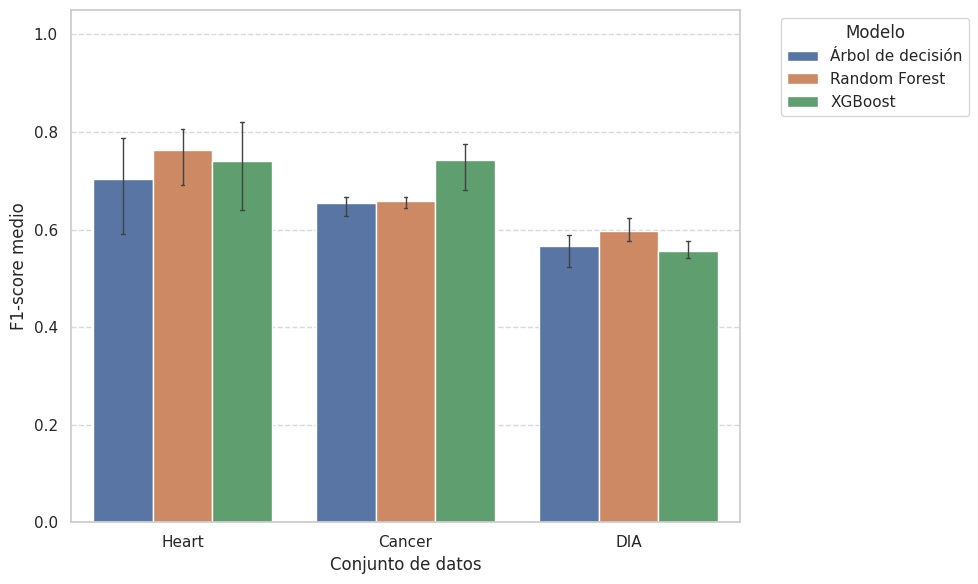

In [47]:
# GRÁFICO 1 - Barras agrupadas de F1 por dataset, una barra por modelo tradicional

plt.figure(figsize=(10, 6))
configurar_rejilla()

sns.barplot(
    data=df_tradicionales, x="Dataset", y="F1-score", hue="Modelo",
    order=ORDEN_DATASETS,
    capsize=0.05, err_kws={"linewidth": 1}, errorbar=("ci", 95)
)

plt.xlabel("Conjunto de datos", fontsize=12)
plt.ylabel("F1-score medio", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
guardar_figura("grafico1_f1_tradicionales")
plt.show()

Figura guardada: tfg_figuras_resultados/grafico2_serializacion.png


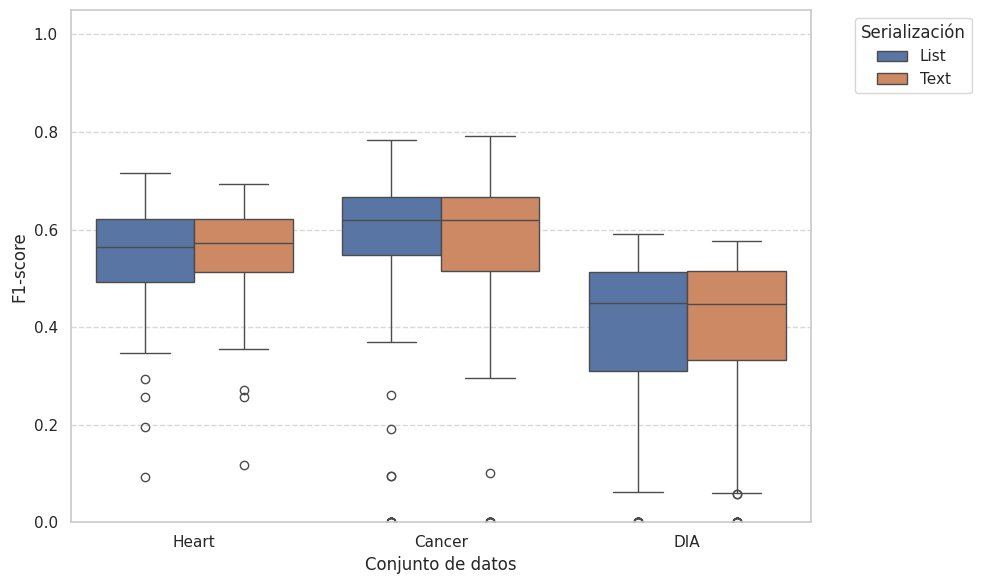

In [48]:
# GRÁFICO 2 - Comparación de F1 list vs text por dataset (boxplot)
# El boxplot muestra la distribución completa sobre todas las configuraciones

plt.figure(figsize=(10, 6))
configurar_rejilla()

sns.boxplot(
    data=df_llms, x="Dataset", y="F1-score", hue="Serializacion",
    order=ORDEN_DATASETS
)

plt.xlabel("Conjunto de datos", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Serialización", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
guardar_figura("grafico2_serializacion")
plt.show()

Figura guardada: tfg_figuras_resultados/grafico3_f1_vs_shots.png


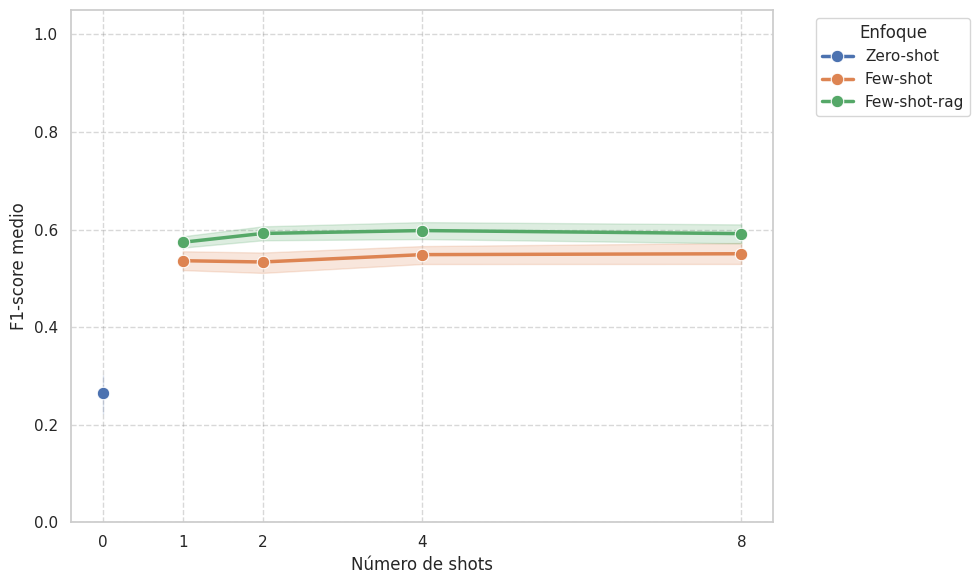

In [49]:
# GRÁFICO 3 - Curva de F1 frente al número de shots
# Tres series: zero-shot (punto en x=0), few-shot y RAG
# Banda de error con la desviación entre semillas

# 1. Construir un DataFrame unificado con una columna 'Enfoque'
# Zero-shot: solo shots=0; Few-shot: shots 1/2/4/8; RAG: shots 1/2/4/8
df_zero = df_llms[df_llms["Estrategia"] == "Zero-shot"].copy()
df_few  = df_llms[df_llms["Estrategia"] == "Few-shot"].copy()
df_rag_auxiliar = df_rag.copy()

df_zero["Enfoque"] = "Zero-shot"
df_few["Enfoque"]  = "Few-shot"
df_rag_auxiliar["Enfoque"] = "Few-shot-rag"

df_curva = pd.concat([df_zero, df_few, df_rag_auxiliar], ignore_index=True)

# 2. Trazar la curva. Seaborn calcula la media y el IC 95% entre las
# observaciones de cada (enfoque, shots), reflejando la variación entre semillas
plt.figure(figsize=(10, 6))
configurar_rejilla()

sns.lineplot(
    data=df_curva, x="Shots", y="F1-score", hue="Enfoque",
    marker="o", linewidth=2.5, markersize=9,
    errorbar=("ci", 95)
)

# El zero-shot es un único punto en x=0
plt.xlabel("Número de shots", fontsize=12)
plt.ylabel("F1-score medio", fontsize=12)
plt.xticks(ORDEN_SHOTS)
plt.ylim(0, 1.05)
plt.legend(title="Enfoque", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
guardar_figura("grafico3_f1_vs_shots")
plt.show()

Figura guardada: tfg_figuras_resultados/grafico4_f1_familia_tamano.png


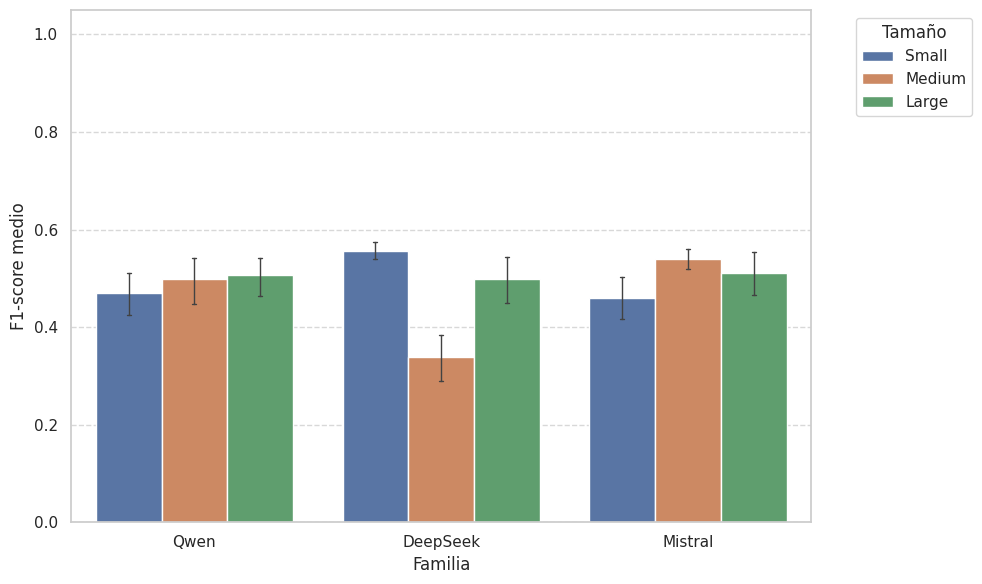

In [50]:
# GRÁFICO 4 - Barras agrupadas de F1 por familia x tamaño (S/M/L)

plt.figure(figsize=(10, 6))
configurar_rejilla()

sns.barplot(
    data=df_llms, x="Familia", y="F1-score", hue="Tamaño",
    order=ORDEN_FAMILIAS, hue_order=ORDEN_TAMANOS,
    capsize=0.05, err_kws={"linewidth": 1}, errorbar=("ci", 95)
)

plt.xlabel("Familia", fontsize=12)
plt.ylabel("F1-score medio", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title="Tamaño", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
guardar_figura("grafico4_f1_familia_tamano")
plt.show()

Figura guardada: tfg_figuras_resultados/grafico5_mejor_llm_vs_trad.png


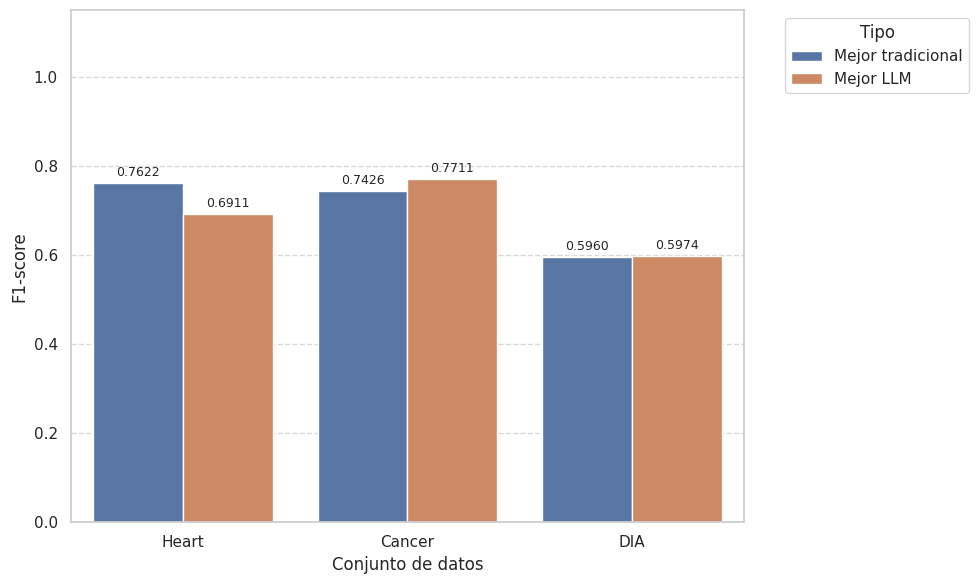

In [51]:
# GRÁFICO 5 - Por dataset, barra del mejor LLM vs mejor tradicional
# Reutiliza los mejores valores calculados en la tabla 6

# 1. Reorganizar tabla6 a formato largo para seaborn
df_mejor_largo = pd.DataFrame({
    "Dataset": list(tabla6["Dataset"]) * 2,
    "Tipo": ["Mejor tradicional"] * len(tabla6) + ["Mejor LLM"] * len(tabla6),
    "F1-score": list(tabla6["F1 tradicional"]) + list(tabla6["F1 LLM"])
})

plt.figure(figsize=(10, 6))
configurar_rejilla()

sns.barplot(
    data=df_mejor_largo, x="Dataset", y="F1-score", hue="Tipo",
    order=ORDEN_DATASETS
)

# Anotar el valor de F1 sobre cada barra
for contenedor in plt.gca().containers:
    plt.gca().bar_label(contenedor, fmt="%.4f", padding=3, fontsize=9)

plt.xlabel("Conjunto de datos", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.ylim(0, 1.15)
plt.legend(title="Tipo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
guardar_figura("grafico5_mejor_llm_vs_trad")
plt.show()

Figura guardada: tfg_figuras_resultados/grafico6_f1_vs_tiempo.png


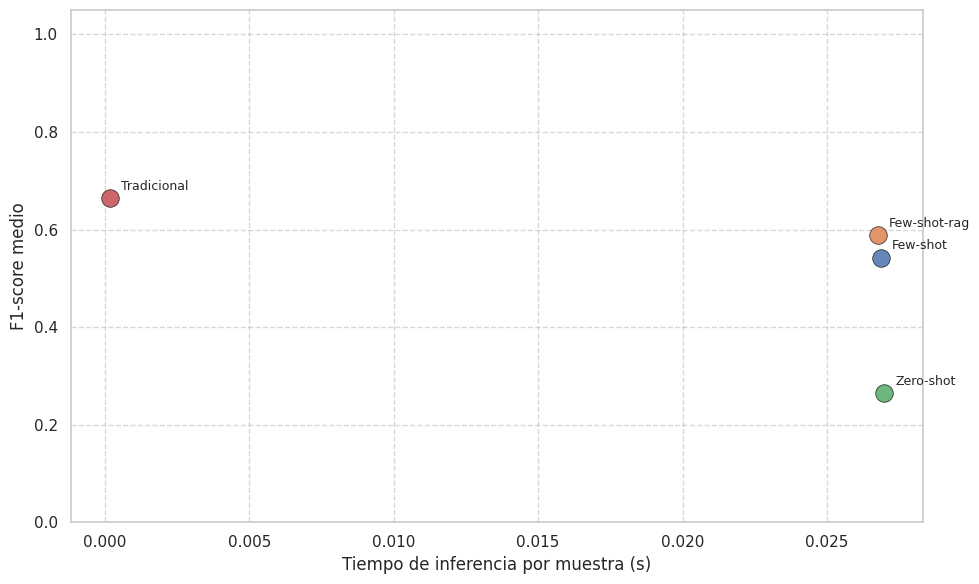

In [52]:
# GRÁFICO 6 - Dispersión F1 vs tiempo de inferencia por muestra
# Un punto por enfoque, permite visualizar el equilibrio rendimiento-coste

# 1. Preparar los puntos de los LLMs (base + RAG) con tiempo por muestra
df_dispersion_llm = pd.concat([df_llms, df_rag], ignore_index=True).copy()
df_dispersion_llm["Tiempo inferencia por muestra (s)"] = (
    df_dispersion_llm["Tiempo inferencia (s)"] / df_dispersion_llm["Muestras"]
)

# 2. Agregar por enfoque (estrategia): F1 medio y tiempo medio por muestra
puntos_llm = df_dispersion_llm.groupby("Estrategia").agg(
    f1=("F1-score", "mean"),
    tiempo=("Tiempo inferencia por muestra (s)", "mean")
).reset_index().rename(columns={"Estrategia": "Enfoque"})

# 3. Agregar el punto de los modelos tradicionales

# Para homogeneizar, se usa el tiempo medio por muestra calculado dataset a dataset
df_tradicionales_dispersion = df_tradicionales.copy()

# Número de muestras de test por dataset
df_tradicionales_dispersion["Muestras"] = df_tradicionales_dispersion["Dataset"].map(muestras_test)
df_tradicionales_dispersion["Tiempo inferencia por muestra (s)"] = (
    df_tradicionales_dispersion["Tiempo inferencia (s)"] / df_tradicionales_dispersion["Muestras"]
)
punto_tradicionales = pd.DataFrame([{
    "Enfoque": "Tradicional",
    "f1": df_tradicionales_dispersion["F1-score"].mean(),
    "tiempo": df_tradicionales_dispersion["Tiempo inferencia por muestra (s)"].mean()
}])

puntos = pd.concat([puntos_llm, punto_tradicionales], ignore_index=True)

# 4. Dibujar la dispersión
plt.figure(figsize=(10, 6))
configurar_rejilla()

for _, fila in puntos.iterrows():
    plt.scatter(fila["tiempo"], fila["f1"], s=160, alpha=0.85,
                label=fila["Enfoque"], edgecolor="black", linewidth=0.5)
    plt.annotate(fila["Enfoque"], (fila["tiempo"], fila["f1"]),
                 textcoords="offset points", xytext=(8, 6), fontsize=9)

plt.xlabel("Tiempo de inferencia por muestra (s)", fontsize=12)
plt.ylabel("F1-score medio", fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
guardar_figura("grafico6_f1_vs_tiempo")
plt.show()

### Cálculos numéricos

In [53]:
print("="*70)
print("CÁLCULOS NUMÉRICOS")
print("="*70)

# 1. Factor de ralentización de inferencia LLM vs tradicional (por muestra)
print("\n--- 1. Factor de ralentización de inferencia (LLM vs tradicional) ---\n")
tiempo_tradicional_muestra = df_tradicionales_dispersion["Tiempo inferencia por muestra (s)"].mean()
tiempo_llm_muestra  = df_dispersion_llm["Tiempo inferencia por muestra (s)"].mean()
factor = tiempo_llm_muestra / tiempo_tradicional_muestra
print(f"  Tiempo medio por muestra tradicional: {tiempo_tradicional_muestra:.6f} s")
print(f"  Tiempo medio por muestra LLM: {tiempo_llm_muestra:.6f} s")
print(f"  Factor de ralentización: x{factor:,.0f}")

# 2. Tasa global de respuestas inválidas por dataset
print("\n--- 2. Tasa global de respuestas inválidas por dataset ---\n")
df_invalidas = pd.concat([df_llms, df_rag], ignore_index=True)
inval_por_dataset = (
    df_invalidas.groupby("Dataset")
    .apply(lambda g: g["Invalidas"].sum() / g["Muestras"].sum())
)
for dataset in ORDEN_DATASETS:
    print(f"  {dataset}: {inval_por_dataset[dataset]:.2%}")

# 3. Tasa global de respuestas inválidas por estrategia
print("\n--- 3. Tasa global de respuestas inválidas por estrategia ---\n")
inval_por_estrategia = (
    df_invalidas.groupby("Estrategia")
    .apply(lambda g: g["Invalidas"].sum() / g["Muestras"].sum())
)
for estrategia, tasa in inval_por_estrategia.items():
    print(f"  {estrategia}: {tasa:.2%}")

# 4. Delta de F1 entre el mejor LLM y el mejor tradicional por dataset
print("\n--- 4. Delta de F1 (mejor LLM - mejor tradicional) por dataset ---\n")
for _, fila in tabla6.iterrows():
    signo = "+" if fila["Diferencia (LLM - tradicional)"] >= 0 else ""
    print(f"  {fila['Dataset']}: {signo}{fila['Diferencia (LLM - tradicional)']:.4f}  "
          f"(LLM {fila['F1 LLM']:.4f} vs trad. {fila['F1 tradicional']:.4f})")

CÁLCULOS NUMÉRICOS

--- 1. Factor de ralentización de inferencia (LLM vs tradicional) ---

  Tiempo medio por muestra tradicional: 0.000171 s
  Tiempo medio por muestra LLM: 0.026820 s
  Factor de ralentización: x157

--- 2. Tasa global de respuestas inválidas por dataset ---

  Heart: 1.70%
  Cancer: 0.30%
  DIA: 0.26%

--- 3. Tasa global de respuestas inválidas por estrategia ---

  Few-shot: 0.90%
  Few-shot-rag: 0.53%
  Zero-shot: 2.10%

--- 4. Delta de F1 (mejor LLM - mejor tradicional) por dataset ---

  Heart: -0.0711  (LLM 0.6911 vs trad. 0.7622)
  Cancer: +0.0285  (LLM 0.7711 vs trad. 0.7426)
  DIA: +0.0014  (LLM 0.5974 vs trad. 0.5960)
